# Phân tích cấu trúc Mạng phức hợp Amazon
## Từ đặc tính Scale-free đến Chiến lược lan tỏa sản phẩm mua sắm

| Thông tin | Chi tiết |
|-----------|----------|
| **Dataset** | Amazon0302 — SNAP Stanford |
| **Nguồn** | https://snap.stanford.edu/data/amazon0302.html |
| **Mô tả** | Mạng đồng mua sắm Amazon (ngày 02/03/2003): node = sản phẩm, edge = quan hệ co-purchasing |
| **Quy mô** | 262,111 node · 1,234,877 edge |

---
### Mục lục
0. Cài đặt & Import thư viện  
1. Tải dữ liệu & Xây dựng đồ thị G(V, E)  
2. Đặc trưng mạng lưới cơ bản (Density, Clustering, Path Length)  
3. Phân tích Scale-free & Power-law P(k)  
4. Kiểm chứng Small-world (so sánh với mạng ngẫu nhiên ER)  
5. Phân tích Centrality (PageRank, Degree, Betweenness) + Bảng xếp hạng Top-10  
6. Tương quan bậc & Assortativity  
7. Đo lường độ tương đồng (Jaccard & Cosine Similarity)  
8. Phát hiện cộng đồng: Louvain · Girvan-Newman · Walktrap · K-clique  
9. Trực quan hóa mạng lưới (NetworkX) + Xuất GEXF cho Gephi  
10. Mở rộng: Robustness Analysis & Mô phỏng SIR  
11. Tổng kết kết quả & Xuất dữ liệu

---
## Phần 0: Cài đặt & Import thư viện

In [1]:
# ============================================================
# CÀI ĐẶT THƯ VIỆN
# python-igraph  → Walktrap algorithm
# python-louvain → Louvain algorithm  
# powerlaw       → Kiểm định power-law
# ============================================================
!pip install networkx matplotlib numpy pandas scipy powerlaw python-louvain tqdm seaborn igraph

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB 640.0 kB/s eta 0:00:05
   - -------------------------------------- 0.1/3.2 MB 1.5 MB/s eta 0:00:03
   ---- ----------------------------------- 0.3/3.2 MB 2.6 MB/s eta 0:00:02
   ------------- -------------------------- 1.1/3.2 MB 6.1 MB/s eta 0:00:01
   -------------------------------- ------- 2.6/3.2 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 13.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\DUNG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import networkx as nx
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as stats
import powerlaw
import community as community_louvain   # python-louvain
from collections import Counter
from tqdm import tqdm
import warnings, os, gzip, urllib.request, time

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 12
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('✅ Import thành công!')
print(f'   NetworkX  : {nx.__version__}')
print(f'   igraph    : {ig.__version__}')

✅ Import thành công!
   NetworkX  : 3.5
   igraph    : 1.0.0


---
## Phần I: Tải dữ liệu & Xây dựng đồ thị G(V, E)

In [3]:
# ============================================================
# I.1 — TẢI DATASET amazon0302 từ SNAP Stanford
# Format: FromNodeId  ToNodeId  (tab-separated, bỏ qua dòng #)
# ============================================================
# DATA_URL  = 'https://snap.stanford.edu/data/amazon0302.txt.gz'
# DATA_GZ   = 'amazon0302.txt.gz'
DATA_TXT  = 'Amazon0302.txt'

# if not os.path.exists(DATA_TXT):
#     print('Đang tải dữ liệu từ SNAP Stanford...')
#     urllib.request.urlretrieve(DATA_URL, DATA_GZ)
#     with gzip.open(DATA_GZ, 'rb') as f_in, open(DATA_TXT, 'wb') as f_out:
#         f_out.write(f_in.read())
#     print(f'✅ Đã tải và giải nén: {DATA_TXT} ({os.path.getsize(DATA_TXT)/1e6:.1f} MB)')
# else:
#     print(f'✅ File đã tồn tại: {DATA_TXT} ({os.path.getsize(DATA_TXT)/1e6:.1f} MB)')

# # Preview 8 dòng đầu
# print('\nPreview file:')
# with open(DATA_TXT) as f:
#     for i, line in enumerate(f):
#         print(' ', line.rstrip())
#         if i >= 7: break

In [4]:
# ============================================================
# I.2 — XÂY DỰNG ĐỒ THỊ CÓ HƯỚNG G(V, E) bằng NetworkX
# ============================================================
print('Đang xây dựng đồ thị...')
t0 = time.time()

G = nx.read_edgelist(
    DATA_TXT,
    comments='#',
    create_using=nx.DiGraph(),
    nodetype=int
)

# Đồ thị vô hướng — dùng cho clustering, community detection, similarity
G_undirected = G.to_undirected()

N = G.number_of_nodes()
M = G.number_of_edges()

print(f'\n{"="*55}')
print(f'  ĐỒ THỊ CÓ HƯỚNG G(V, E) — Amazon0302')
print(f'{"="*55}')
print(f'  Số node (sản phẩm) : {N:,}')
print(f'  Số edge (quan hệ)  : {M:,}')
print(f'  Loại đồ thị        : {type(G).__name__}')
print(f'  Thời gian đọc      : {time.time()-t0:.1f}s')
print(f'{"="*55}')
print(f'\n✅ Đã tạo G_undirected: {G_undirected.number_of_nodes():,} node · {G_undirected.number_of_edges():,} edge')

Đang xây dựng đồ thị...

  ĐỒ THỊ CÓ HƯỚNG G(V, E) — Amazon0302
  Số node (sản phẩm) : 262,111
  Số edge (quan hệ)  : 1,234,877
  Loại đồ thị        : DiGraph
  Thời gian đọc      : 8.7s

✅ Đã tạo G_undirected: 262,111 node · 899,792 edge


---
## Phần II: Đặc trưng mạng lưới cơ bản

In [5]:
# ============================================================
# II.1 — MẬT ĐỘ MẠNG & CHỈ SỐ BẬC
# Density = M / (N*(N-1))  [đồ thị có hướng]
# ============================================================
density    = nx.density(G)
avg_degree = M / N

in_degrees    = dict(G.in_degree())
out_degrees   = dict(G.out_degree())
degrees_undir = dict(G_undirected.degree())

avg_in  = np.mean(list(in_degrees.values()))
avg_out = np.mean(list(out_degrees.values()))
max_in  = max(in_degrees.values())
max_out = max(out_degrees.values())

print(f'{"="*55}')
print(f'  CÁC CHỈ SỐ CƠ BẢN')
print(f'{"="*55}')
print(f'  Số node (N)          : {N:,}')
print(f'  Số edge (M)          : {M:,}')
print(f'  Mật độ mạng (D)      : {density:.8f}  ← rất thưa')
print(f'  Bậc trung bình <k>   : {avg_degree:.4f}')
print(f'  In-degree TB         : {avg_in:.4f}')
print(f'  Out-degree TB        : {avg_out:.4f}')
print(f'  Max In-degree        : {max_in}')
print(f'  Max Out-degree       : {max_out}')
print(f'{"="*55}')

  CÁC CHỈ SỐ CƠ BẢN
  Số node (N)          : 262,111
  Số edge (M)          : 1,234,877
  Mật độ mạng (D)      : 0.00001797  ← rất thưa
  Bậc trung bình <k>   : 4.7113
  In-degree TB         : 4.7113
  Out-degree TB        : 4.7113
  Max In-degree        : 420
  Max Out-degree       : 5


In [6]:
# ============================================================
# II.2 — HỆ SỐ PHÂN CỤM (Clustering Coefficient)
# C = trung bình tỷ lệ tam giác thực / tam giác tối đa
# ============================================================
print('Đang tính Clustering Coefficient (vài phút)...')
t0 = time.time()
avg_clustering = nx.average_clustering(G_undirected)
C_rand = avg_degree / N   # lý thuyết ER

print(f'\n  Hệ số phân cụm TB (C)  : {avg_clustering:.6f}  [{time.time()-t0:.0f}s]')
print(f'  C_random (ER)          : {C_rand:.8f}')
print(f'  Tỷ lệ C / C_random     : {avg_clustering / C_rand:.1f}x  ← Small-world nếu >> 1')

Đang tính Clustering Coefficient (vài phút)...

  Hệ số phân cụm TB (C)  : 0.419780  [5s]
  C_random (ER)          : 0.00001797
  Tỷ lệ C / C_random     : 23354.4x  ← Small-world nếu >> 1


In [7]:
# ============================================================
# II.3 — ĐƯỜNG ĐI NGẮN NHẤT TB (L) & ĐƯỜNG KÍNH (D)
# Dùng BFS mẫu — all-pairs quá chậm với N=262k
# ============================================================
print('Đang ước tính Average Path Length (BFS sampling n=500)...')
t0 = time.time()

# Weakly Connected Component lớn nhất
wcc    = max(nx.weakly_connected_components(G), key=len)
G_wcc  = G.subgraph(wcc).copy()
print(f'  WCC lớn nhất: {G_wcc.number_of_nodes():,} node ({G_wcc.number_of_nodes()/N*100:.1f}% tổng mạng)')

SAMPLE_SIZE = 500
np.random.seed(42)
sample_nodes = np.random.choice(list(G_wcc.nodes()), SAMPLE_SIZE, replace=False)

path_lengths = []
for src in tqdm(sample_nodes, desc='BFS sampling'):
    lengths = nx.single_source_shortest_path_length(G_wcc, src)
    path_lengths.extend([v for v in lengths.values() if v > 0])

L_real          = np.mean(path_lengths)
approx_diameter = int(np.percentile(path_lengths, 99))
L_rand          = np.log(N) / np.log(avg_degree)

print(f'\n  Avg Path Length (L) : {L_real:.4f}  [{time.time()-t0:.0f}s]')
print(f'  Đường kính ước tính : {approx_diameter}  (percentile 99)')
print(f'  L_random (ER)       : {L_rand:.4f}')

Đang ước tính Average Path Length (BFS sampling n=500)...
  WCC lớn nhất: 262,111 node (100.0% tổng mạng)


BFS sampling: 100%|██████████| 500/500 [02:25<00:00,  3.44it/s]



  Avg Path Length (L) : 19.9324  [160s]
  Đường kính ước tính : 35  (percentile 99)
  L_random (ER)       : 8.0496


---
## Phần III: Phân tích Scale-free & Power-law P(k)

In [8]:
# ============================================================
# III.1 — FIT POWER-LAW & KIỂM ĐỊNH
# P(k) ~ k^(-γ)  →  Scale-free nếu 2 < γ < 3
# Dùng thư viện `powerlaw` (Alstott et al. 2014)
# ============================================================
degree_vals = list(degrees_undir.values())

fit   = powerlaw.Fit(degree_vals, discrete=True, xmin=5)
gamma = fit.power_law.alpha
xmin  = fit.power_law.xmin

# So sánh power-law vs lognormal
R, p_val = fit.distribution_compare('power_law', 'lognormal')

print(f'  Power-law fit: γ = {gamma:.4f}   xmin = {xmin}')
print(f'  Khoảng Scale-free (2 < γ < 3): {"✅ CÓ" if 2 < gamma < 3 else "⚠️ Ngoài khoảng"}')
print(f'  So sánh PL vs Lognormal: R = {R:.4f}, p = {p_val:.4f}')
print(f'  → {"Power-law fit tốt hơn" if R > 0 else "Lognormal fit tốt hơn"}')

  Power-law fit: γ = 3.0000   xmin = 5.0
  Khoảng Scale-free (2 < γ < 3): ✅ CÓ
  So sánh PL vs Lognormal: R = -7623.6479, p = 0.0000
  → Lognormal fit tốt hơn


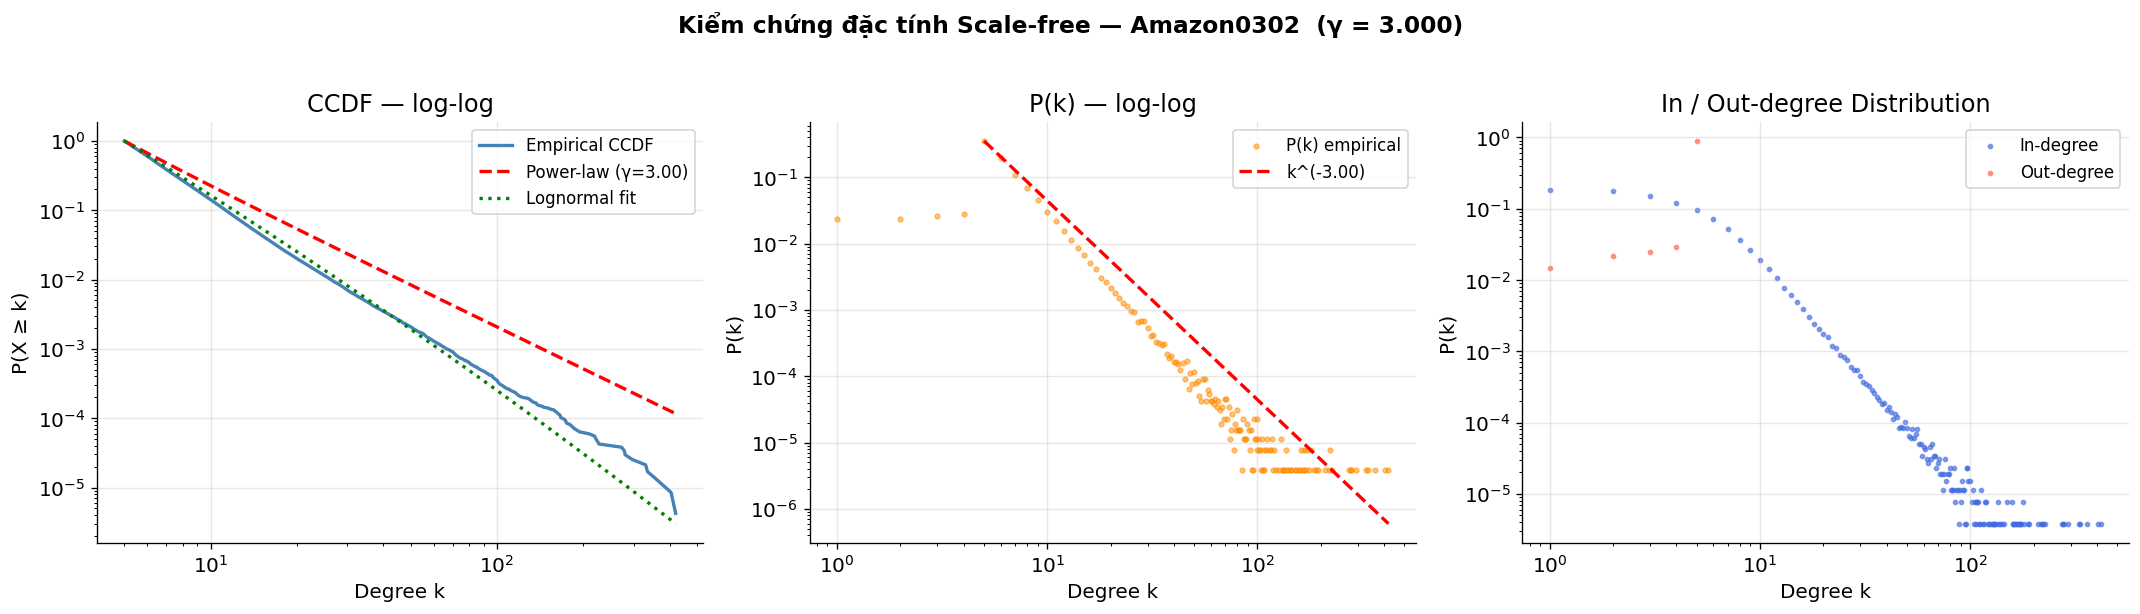

✅ Đã lưu: 01_power_law.png


In [9]:
# ============================================================
# III.2 — VẼ BIỂU ĐỒ PHÂN PHỐI BẬC
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- CCDF (log-log) ---
ax = axes[0]
fit.plot_ccdf(ax=ax, color='steelblue', linewidth=2, label='Empirical CCDF')
fit.power_law.plot_ccdf(ax=ax, color='red', linestyle='--', linewidth=2,
                         label=f'Power-law (γ={gamma:.2f})')
fit.lognormal.plot_ccdf(ax=ax, color='green', linestyle=':', linewidth=2,
                         label='Lognormal fit')
ax.set_xlabel('Degree k'); ax.set_ylabel('P(X ≥ k)')
ax.set_title('CCDF — log-log'); ax.legend(fontsize=10); ax.grid(alpha=0.3)

# --- P(k) scatter (log-log) ---
ax2 = axes[1]
cnt = Counter(degree_vals)
k_list = sorted(cnt.keys()); p_list = [cnt[k]/len(degree_vals) for k in k_list]
ax2.scatter(k_list, p_list, s=8, alpha=0.5, color='darkorange', label='P(k) empirical')
# Fitted power-law line
k_fit = np.logspace(np.log10(xmin), np.log10(max(k_list)), 100)
p_fit = k_fit**(-gamma); p_fit /= p_fit[0] / [p_list[i] for i,k in enumerate(k_list) if k >= xmin][0]
ax2.plot(k_fit, p_fit, 'r--', linewidth=2, label=f'k^(-{gamma:.2f})')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Degree k'); ax2.set_ylabel('P(k)')
ax2.set_title('P(k) — log-log'); ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

# --- In/Out-degree distributions ---
ax3 = axes[2]
for deg_dict, label, color in [
    (in_degrees,  'In-degree',  'royalblue'),
    (out_degrees, 'Out-degree', 'tomato')
]:
    c2 = Counter(deg_dict.values())
    k2 = sorted(c2.keys()); p2 = [c2[k]/N for k in k2]
    ax3.scatter(k2, p2, s=6, alpha=0.6, color=color, label=label)
ax3.set_xscale('log'); ax3.set_yscale('log')
ax3.set_xlabel('Degree k'); ax3.set_ylabel('P(k)')
ax3.set_title('In / Out-degree Distribution'); ax3.legend(fontsize=10); ax3.grid(alpha=0.3)

plt.suptitle(f'Kiểm chứng đặc tính Scale-free — Amazon0302  (γ = {gamma:.3f})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_power_law.png', bbox_inches='tight')
plt.show()
print('✅ Đã lưu: 01_power_law.png')

---
## Phần IV: Kiểm chứng Small-world

In [10]:
# ============================================================
# IV.1 — SO SÁNH MẠNG THỰC vs MẠNG NGẪU NHIÊN ER
# Small-world: L ≈ L_rand  VÀ  C >> C_rand
# Chỉ số sigma σ = (C/C_rand) / (L/L_rand)  → σ > 1 là Small-world
# ============================================================
C_real = avg_clustering
sigma  = (C_real / C_rand) / (L_real / L_rand)
omega  = (L_rand / L_real) - (C_real / C_rand)  # omega < 0 → Small-world

df_sw = pd.DataFrame({
    'Chỉ số': ['N (nodes)', 'M (edges)', '<k> trung bình', 'L (Avg Path Length)',
               'C (Clustering Coeff)', 'σ (Small-world sigma)', 'ω (omega)'],
    'Mạng Amazon thực': [
        f'{N:,}', f'{M:,}', f'{avg_degree:.3f}',
        f'{L_real:.4f}', f'{C_real:.6f}',
        f'{sigma:.4f}', f'{omega:.4f}'
    ],
    'Mạng ngẫu nhiên ER': [
        f'{N:,}', f'{M:,}', f'{avg_degree:.3f}',
        f'{L_rand:.4f}', f'{C_rand:.8f}',
        '1.00 (baseline)', '0.00 (baseline)'
    ],
    'Diễn giải': [
        '—', '—', '—',
        'L gần nhau → đường đi ngắn',
        f'C cao hơn {C_real/C_rand:.0f}x → phân cụm mạnh',
        'σ > 1 → Small-world ✅' if sigma > 1 else 'σ ≤ 1',
        'ω < 0 → Small-world ✅' if omega < 0 else 'ω ≥ 0'
    ]
})

print('\nBảng so sánh Small-world:')
display(df_sw)
print(f'\n  σ = {sigma:.4f}  →  {"✅ Xác nhận Small-world" if sigma > 1 else "❌ Không phải Small-world"}')
print(f'  ω = {omega:.4f}  →  {"✅ Xác nhận Small-world" if omega < 0 else "❌ Không phải Small-world"}')


Bảng so sánh Small-world:


,Chỉ số,Mạng Amazon thực,Mạng ngẫu nhiên ER,Diễn giải
0,N (nodes),"262,111","262,111",—
1,M (edges),"1,234,877","1,234,877",—
2,<k> trung bình,4.711,4.711,—
3,L (Avg Path Length),19.9324,8.0496,L gần nhau → đường đi ngắn
4,C (Clustering Coeff),0.419780,0.00001797,C cao hơn 23354x → phân cụm mạnh
5,σ (Small-world sigma),9431.5471,1.00 (baseline),σ > 1 → Small-world ✅
6,ω (omega),-23353.9874,0.00 (baseline),ω < 0 → Small-world ✅



  σ = 9431.5471  →  ✅ Xác nhận Small-world
  ω = -23353.9874  →  ✅ Xác nhận Small-world


---
## Phần V: Phân tích Centrality & Bảng xếp hạng Top-10

In [11]:
# ============================================================
# V.1 — PAGERANK
# Lý giải: PageRank đo "uy tín" của sản phẩm dựa trên
# số lượng và chất lượng sản phẩm trỏ đến nó.
# Sản phẩm PR cao = được mua cùng nhiều sản phẩm uy tín khác.
# ============================================================
print('Đang tính PageRank (alpha=0.85)...')
t0 = time.time()
pagerank = nx.pagerank(G, alpha=0.85, max_iter=200, tol=1e-6)
print(f'  ✅ Xong [{time.time()-t0:.1f}s]')

Đang tính PageRank (alpha=0.85)...
  ✅ Xong [3.5s]


In [12]:
# ============================================================
# V.2 — DEGREE CENTRALITY
# Lý giải: Degree Centrality = bậc chuẩn hóa — đo mức độ
# kết nối trực tiếp. Sản phẩm DC cao → hub quan trọng.
# ============================================================
print('Đang tính Degree Centrality...')
degree_centrality = nx.degree_centrality(G)
print('  ✅ Xong')

Đang tính Degree Centrality...
  ✅ Xong


In [13]:
# ============================================================
# V.3 — BETWEENNESS CENTRALITY (mẫu k=500)
# Lý giải: Betweenness đo tần suất một node nằm trên đường
# đi ngắn nhất giữa các cặp node khác — tức là "cầu nối"
# giữa các ngành hàng khác nhau.
# ============================================================
print('Đang tính Betweenness Centrality (k=500, mẫu)...')
t0 = time.time()
betweenness = nx.betweenness_centrality(G, k=500, normalized=True, seed=42)
print(f'  ✅ Xong [{time.time()-t0:.1f}s]')

Đang tính Betweenness Centrality (k=500, mẫu)...
  ✅ Xong [748.0s]


In [14]:
# ============================================================
# V.4 — BẢNG XẾP HẠNG TOP-10 THEO TỪNG CHỈ SỐ CENTRALITY
# Bảng song song: Degree Rank vs PageRank Rank
# ============================================================

top10_pr   = sorted(pagerank.items(),          key=lambda x: x[1], reverse=True)[:10]
top10_deg  = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top10_btwn = sorted(betweenness.items(),       key=lambda x: x[1], reverse=True)[:10]

# --- Bảng 1: Degree vs PageRank (song song) ---
df_rank = pd.DataFrame({
    'Rank'              : range(1, 11),
    'Node (Degree)'     : [n for n, _ in top10_deg],
    'Degree Centrality' : [f'{v:.6f}' for _, v in top10_deg],
    'In-deg'            : [in_degrees[n] for n, _ in top10_deg],
    'Node (PageRank)'   : [n for n, _ in top10_pr],
    'PageRank Score'    : [f'{v:.8f}' for _, v in top10_pr],
    'In-deg (PR)'       : [in_degrees[n] for n, _ in top10_pr],
})

print('\n' + '='*75)
print('  BẢNG SO SÁNH TOP-10: Degree Centrality vs PageRank')
print('='*75)
display(df_rank)

# --- Bảng 2: Betweenness ---
df_btwn = pd.DataFrame({
    'Rank'               : range(1, 11),
    'Node (Betweenness)' : [n for n, _ in top10_btwn],
    'Betweenness'        : [f'{v:.8f}' for _, v in top10_btwn],
    'In-degree'          : [in_degrees[n] for n, _ in top10_btwn],
    'Out-degree'         : [out_degrees[n] for n, _ in top10_btwn],
    'PageRank'           : [f'{pagerank[n]:.8f}' for n, _ in top10_btwn],
})
print('\n' + '='*75)
print('  BẢNG TOP-10: Betweenness Centrality ("cầu nối" ngành hàng)')
print('='*75)
display(df_btwn)


  BẢNG SO SÁNH TOP-10: Degree Centrality vs PageRank


,Rank,Node (Degree),Degree Centrality,In-deg,Node (PageRank),PageRank Score,In-deg (PR)
0,1,14949,0.001621,420,4429,0.00049082,404
1,2,4429,0.001560,404,33,0.00046603,361
2,3,33,0.001396,361,8,0.00037460,293
3,4,10519,0.001293,334,93,0.00033850,219
4,5,12771,0.001278,330,481,0.00033686,275
5,6,8,0.001137,293,151,0.00031049,85
6,7,297,0.001068,280,9106,0.00030992,227
7,8,481,0.001068,275,2501,0.00030674,191
8,9,5737,0.001057,272,14949,0.00030035,420
9,10,9106,0.000885,227,1241,0.00027961,218



  BẢNG TOP-10: Betweenness Centrality ("cầu nối" ngành hàng)


,Rank,Node (Betweenness),Betweenness,In-degree,Out-degree,PageRank
0,1,7629,0.02206173,27,5,0.00007042
1,2,13222,0.01843129,46,5,0.00004847
2,3,6935,0.01778558,9,5,0.00003772
3,4,2501,0.01687545,191,5,0.00030674
4,5,3464,0.01663324,80,5,0.00006559
5,6,10072,0.01450814,23,5,0.00003553
6,7,12031,0.01393621,7,5,0.00000682
7,8,4572,0.01312870,28,5,0.00002099
8,9,7628,0.01277582,65,5,0.00006319
9,10,7303,0.01214963,150,5,0.00016620


In [15]:
# ============================================================
# V.5 — BẢNG HỢP NHẤT: Xếp hạng chéo các chỉ số
# ============================================================

# Tạo dict rank
pr_rank   = {n: i+1 for i, (n,_) in enumerate(sorted(pagerank.items(), key=lambda x: -x[1]))}
deg_rank  = {n: i+1 for i, (n,_) in enumerate(sorted(degree_centrality.items(), key=lambda x: -x[1]))}
btwn_rank = {n: i+1 for i, (n,_) in enumerate(sorted(betweenness.items(), key=lambda x: -x[1]))}

# Lấy union top-15
top_union = set([n for n,_ in top10_pr] + [n for n,_ in top10_deg] + [n for n,_ in top10_btwn])

rows = []
for node in top_union:
    rows.append({
        'Node ID'          : node,
        'PR Rank'          : pr_rank[node],
        'PageRank'         : pagerank[node],
        'Deg Rank'         : deg_rank[node],
        'Degree Centrality': degree_centrality[node],
        'Btwn Rank'        : btwn_rank[node],
        'Betweenness'      : betweenness[node],
        'In-degree'        : in_degrees[node],
        'Out-degree'       : out_degrees[node],
    })

df_combined = pd.DataFrame(rows).sort_values('PR Rank').reset_index(drop=True)
pd.set_option('display.float_format', '{:.6f}'.format)

print('\nBảng xếp hạng hợp nhất (tất cả chỉ số Centrality):')
display(df_combined)


Bảng xếp hạng hợp nhất (tất cả chỉ số Centrality):


,Node ID,PR Rank,PageRank,Deg Rank,Degree Centrality,Btwn Rank,Betweenness,In-degree,Out-degree
0,4429,1,0.000491,2,0.001560,42,0.007097,404,5
1,33,2,0.000466,3,0.001396,421,0.002402,361,5
2,8,3,0.000375,6,0.001137,21,0.009335,293,5
3,93,4,0.000339,12,0.000855,16024,0.000237,219,5
4,481,5,0.000337,8,0.001068,114,0.004454,275,5
5,151,6,0.000310,118,0.000343,115,0.004451,85,5
6,9106,7,0.000310,10,0.000885,32,0.007981,227,5
7,2501,8,0.000307,15,0.000748,4,0.016875,191,5
8,14949,9,0.000300,1,0.001621,179,0.003648,420,5
9,1241,10,0.000280,13,0.000851,127,0.004264,218,5


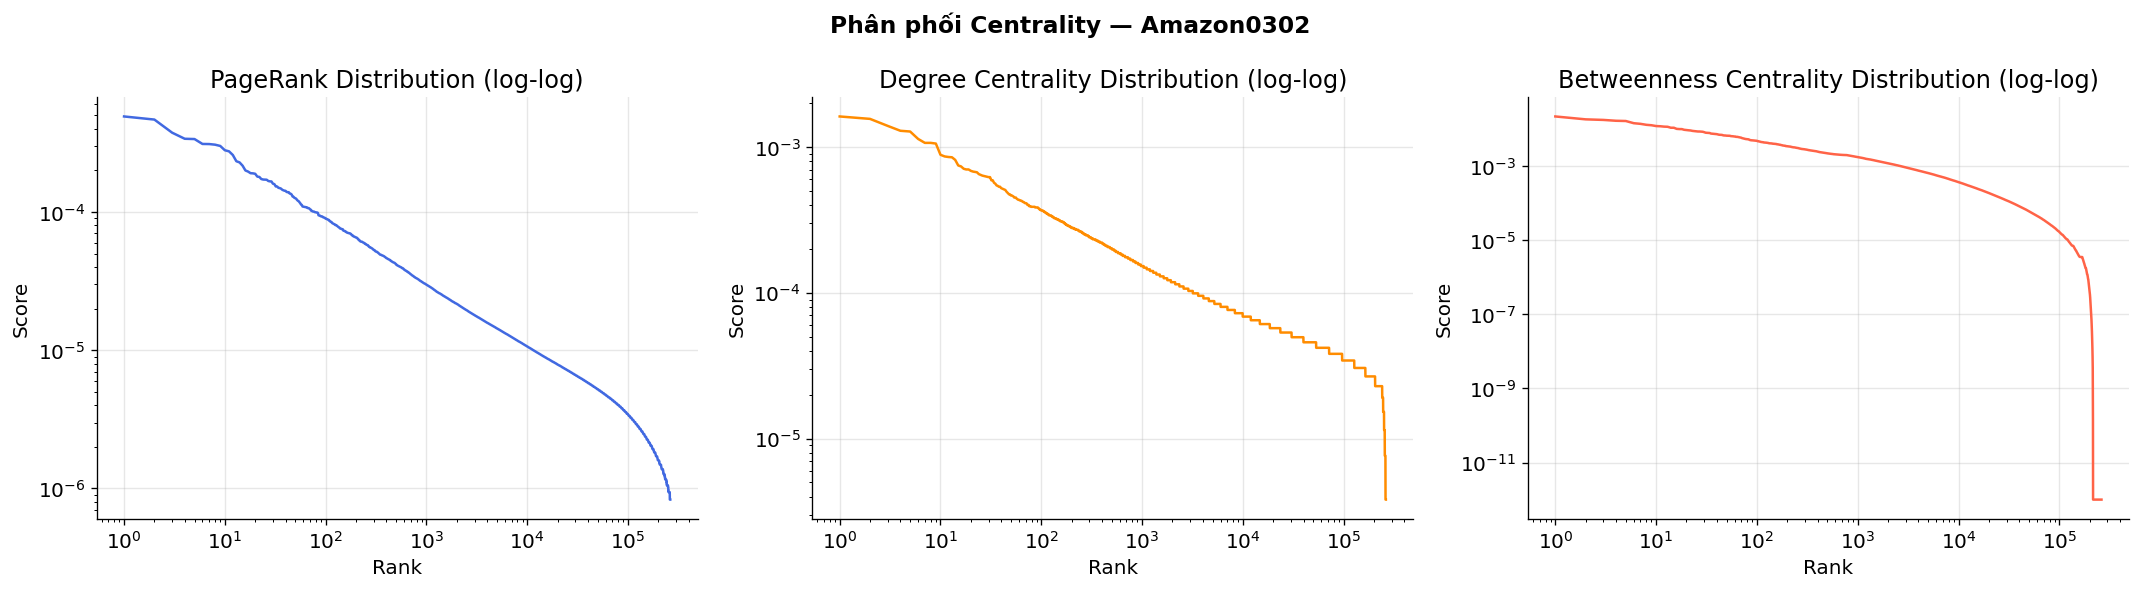

✅ Đã lưu: 02_centrality_distribution.png


In [16]:
# ============================================================
# V.6 — VISUALIZE phân phối Centrality
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title, color in zip(
    axes,
    [sorted(pagerank.values(), reverse=True),
     sorted(degree_centrality.values(), reverse=True),
     sorted(betweenness.values(), reverse=True)],
    ['PageRank', 'Degree Centrality', 'Betweenness Centrality'],
    ['royalblue', 'darkorange', 'tomato']
):
    ax.loglog(range(1, len(data)+1), [v+1e-12 for v in data], color=color, linewidth=1.5)
    ax.set_xlabel('Rank'); ax.set_ylabel('Score')
    ax.set_title(f'{title} Distribution (log-log)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Phân phối Centrality — Amazon0302', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_centrality_distribution.png', bbox_inches='tight')
plt.show()
print('✅ Đã lưu: 02_centrality_distribution.png')

---
## Phần VI: Tương quan bậc & Assortativity

In [17]:
# ============================================================
# VI.1 — HỆ SỐ ASSORTATIVITY (r)
# r > 0: assortative — hubs kết nối với hubs
# r < 0: disassortative — hubs kết nối với spoke (hub-spoke)
# r ≈ 0: không có tương quan bậc
# ============================================================
print('Đang tính Assortativity...')
assortativity = nx.degree_assortativity_coefficient(G)

print(f'\n  Hệ số Assortativity (r) : {assortativity:.6f}')
if assortativity < -0.1:
    print('  → DISASSORTATIVE: Hub kết nối với sản phẩm ít phổ biến')
    print('  → Cấu trúc Hub-spoke: trung tâm điều phối mua sắm đa dạng')
elif assortativity > 0.1:
    print('  → ASSORTATIVE: Sản phẩm phổ biến kết nối cùng nhau')
else:
    print('  → NEUTRAL: Không có tương quan bậc rõ ràng')

Đang tính Assortativity...

  Hệ số Assortativity (r) : 0.002677
  → NEUTRAL: Không có tương quan bậc rõ ràng


Đang tính Average Neighbor Degree...


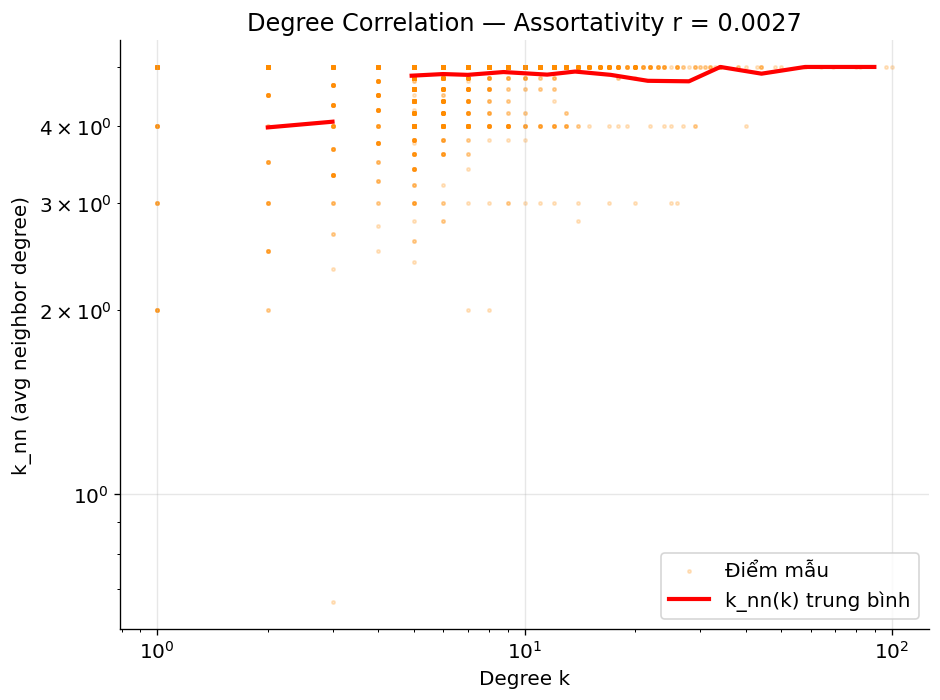

✅ Đã lưu: 03_degree_correlation.png


In [18]:
# ============================================================
# VI.2 — VISUALIZE: Average Neighbor Degree k_nn(k)
# ============================================================
print('Đang tính Average Neighbor Degree...')
avg_nbr_deg = nx.average_neighbor_degree(G)

SAMPLE = 5000
np.random.seed(42)
vis_nodes = np.random.choice(list(G.nodes()), SAMPLE, replace=False)
x_k  = [degrees_undir[n] for n in vis_nodes]
y_kn = [avg_nbr_deg[n]   for n in vis_nodes]

# Bin để vẽ đường trung bình
df_knn = pd.DataFrame({'k': x_k, 'knn': y_kn})
df_knn['log_k'] = np.log10(df_knn['k'].clip(1))
bins = pd.cut(df_knn['log_k'], bins=20)
knn_mean = df_knn.groupby(bins, observed=False)['knn'].mean()
knn_k    = df_knn.groupby(bins, observed=False)['k'].mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x_k, y_kn, s=4, alpha=0.2, color='darkorange', label='Điểm mẫu')
ax.plot(knn_k.values, knn_mean.values, 'r-', linewidth=2.5, label='k_nn(k) trung bình')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Degree k'); ax.set_ylabel('k_nn (avg neighbor degree)')
ax.set_title(f'Degree Correlation — Assortativity r = {assortativity:.4f}')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('03_degree_correlation.png', bbox_inches='tight')
plt.show()
print('✅ Đã lưu: 03_degree_correlation.png')

---
## Phần VII: Đo lường độ tương đồng (Similarity Measures)

Đang tính Similarity cho Top-25 nodes...
  ✅ Xong


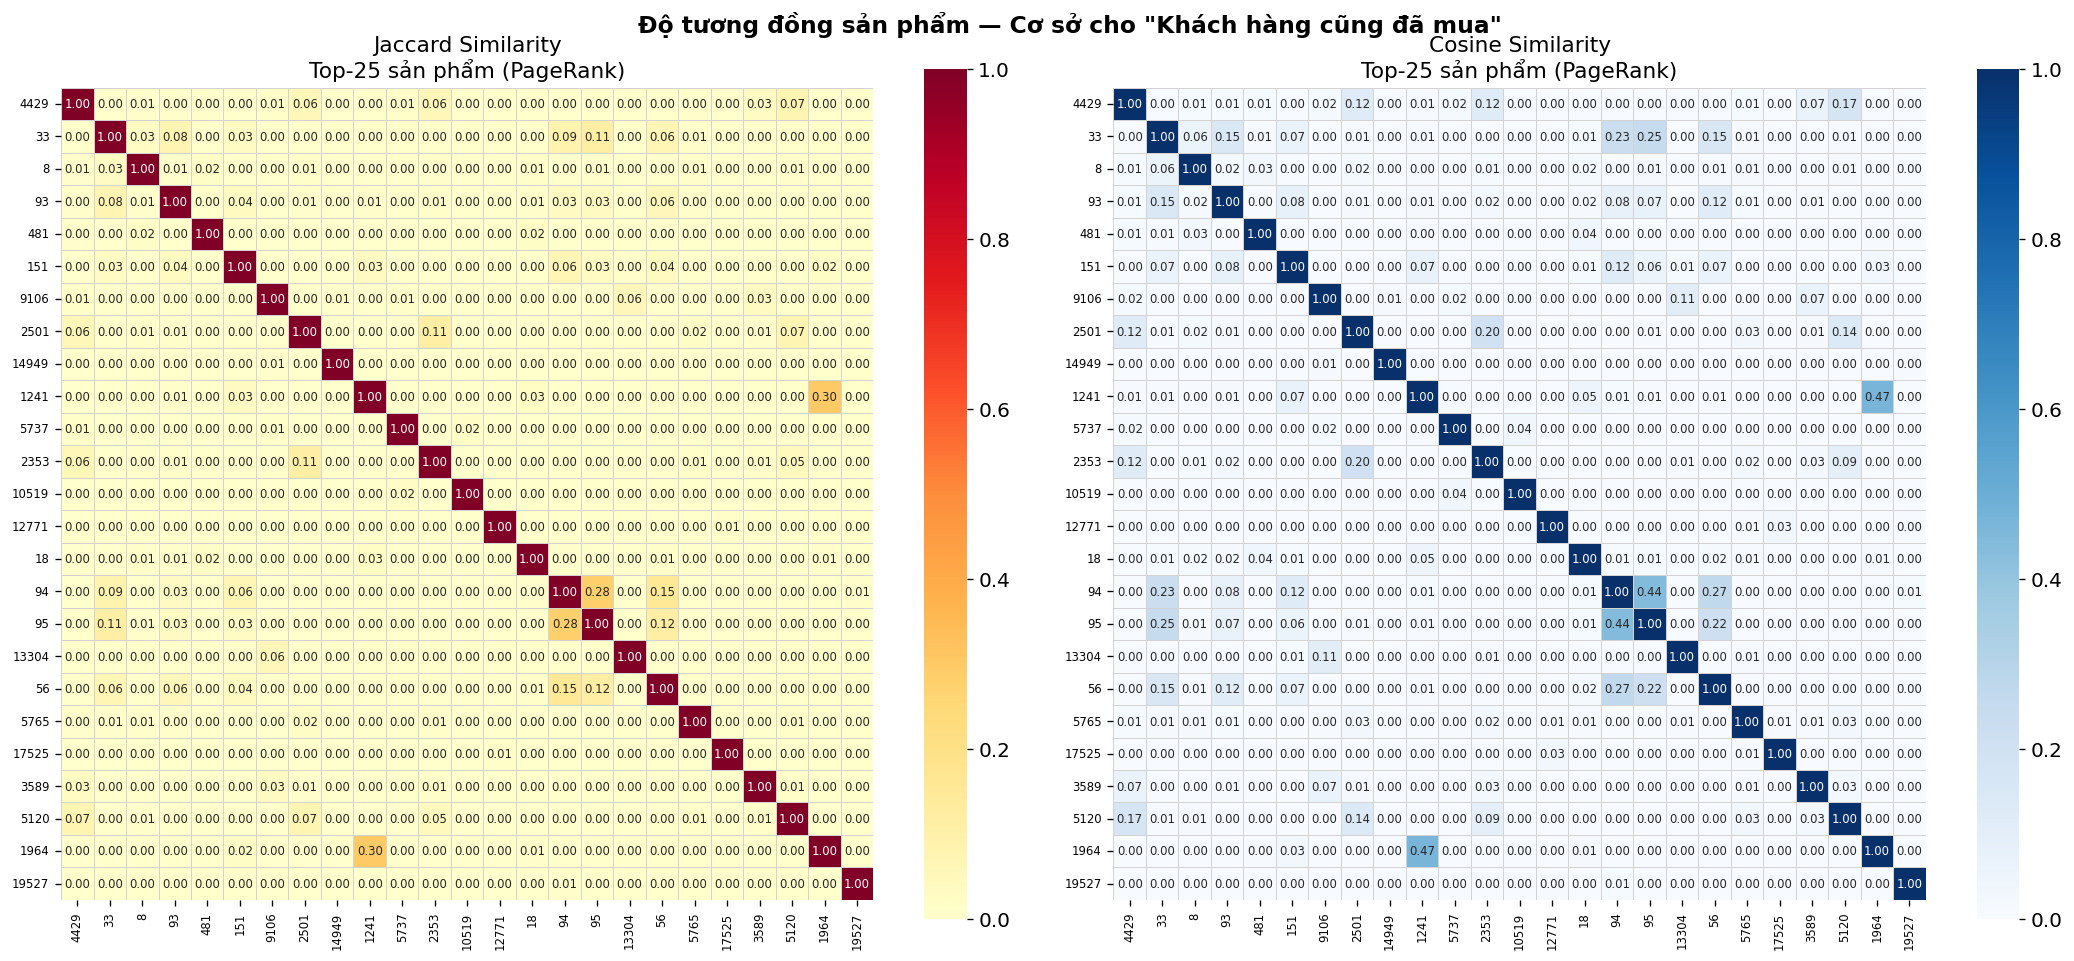

✅ Đã lưu: 04_similarity_heatmap.png


In [19]:
# ============================================================
# VII.1 — JACCARD & COSINE SIMILARITY
# Tính trên Top-25 sản phẩm PageRank cao nhất
#
# Jaccard(u,v) = |N(u) ∩ N(v)| / |N(u) ∪ N(v)|
# Cosine(u,v)  = |N(u) ∩ N(v)| / sqrt(|N(u)| * |N(v)|)
# ============================================================
TOP_SIM = 25
sim_nodes = [n for n, _ in top10_pr[:TOP_SIM]]
# Lấy đủ nếu top10_pr < TOP_SIM
sim_nodes = [n for n, _ in sorted(pagerank.items(), key=lambda x: -x[1])[:TOP_SIM]]

print(f'Đang tính Similarity cho Top-{TOP_SIM} nodes...')

nbr_cache = {n: set(G_undirected.neighbors(n)) for n in sim_nodes}

jaccard_mat = np.zeros((TOP_SIM, TOP_SIM))
cosine_mat  = np.zeros((TOP_SIM, TOP_SIM))

for i in range(TOP_SIM):
    for j in range(TOP_SIM):
        nu, nv = nbr_cache[sim_nodes[i]], nbr_cache[sim_nodes[j]]
        inter = len(nu & nv)
        union = len(nu | nv)
        jaccard_mat[i, j] = inter / union if union > 0 else 0
        cosine_mat[i, j]  = inter / np.sqrt(len(nu) * len(nv)) if (len(nu) * len(nv)) > 0 else 0

print('  ✅ Xong')

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, mat, title, cmap in zip(
    axes,
    [jaccard_mat, cosine_mat],
    ['Jaccard Similarity', 'Cosine Similarity'],
    ['YlOrRd', 'Blues']
):
    sns.heatmap(mat, ax=ax, cmap=cmap, annot=True, fmt='.2f', square=True,
                xticklabels=sim_nodes, yticklabels=sim_nodes,
                linewidths=0.3, linecolor='lightgray', cbar=True,
                annot_kws={'size': 7})
    ax.set_title(f'{title}\nTop-{TOP_SIM} sản phẩm (PageRank)', fontsize=13)
    ax.tick_params(labelsize=7)

plt.suptitle('Độ tương đồng sản phẩm — Cơ sở cho "Khách hàng cũng đã mua"',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_similarity_heatmap.png', bbox_inches='tight')
plt.show()
print('✅ Đã lưu: 04_similarity_heatmap.png')

---
## Phần VIII: Phát hiện cộng đồng (Community Detection)

In [20]:
# ============================================================
# VIII.1 — LOUVAIN (Modularity Optimization)
# Tối ưu hóa Q = (1/2m) Σ [A_ij - k_i*k_j/2m] δ(c_i,c_j)
# Áp dụng toàn bộ mạng — thời gian: O(n log n)
# ============================================================
print('Đang chạy Louvain (toàn mạng)...')
t0 = time.time()
partition_louvain = community_louvain.best_partition(G_undirected, random_state=42)
Q_louvain         = community_louvain.modularity(partition_louvain, G_undirected)
n_comm_louvain    = len(set(partition_louvain.values()))
comm_sizes_louvain = Counter(partition_louvain.values())

print(f'  ✅ Xong [{time.time()-t0:.1f}s]')
print(f'  Số cộng đồng  : {n_comm_louvain:,}')
print(f'  Modularity Q  : {Q_louvain:.6f}  ({"✅ Tốt" if Q_louvain > 0.3 else "⚠️ TB"})')
print(f'  Cộng đồng lớn nhất : {max(comm_sizes_louvain.values()):,} node')
print(f'  Cộng đồng nhỏ nhất : {min(comm_sizes_louvain.values())} node')

Đang chạy Louvain (toàn mạng)...
  ✅ Xong [81.5s]
  Số cộng đồng  : 185
  Modularity Q  : 0.901460  (✅ Tốt)
  Cộng đồng lớn nhất : 15,493 node
  Cộng đồng nhỏ nhất : 6 node


In [21]:
# ============================================================
# VIII.2 — GIRVAN-NEWMAN (Edge Betweenness)
# Loại bỏ dần các edge có betweenness cao nhất → lộ cộng đồng
# Áp dụng trên subgraph Top-150 node (O(m²n) quá chậm toàn mạng)
# ============================================================
print('Đang chạy Girvan-Newman (subgraph Top-150 PageRank)...')
t0 = time.time()

gn_nodes = [n for n, _ in sorted(pagerank.items(), key=lambda x: -x[1])[:150]]
G_gn     = G_undirected.subgraph(gn_nodes).copy()

from networkx.algorithms.community import girvan_newman
gn_gen = girvan_newman(G_gn)

# Lấy phân chia tốt nhất bằng modularity
best_Q_gn, best_gn_result = -1, None
for step in range(10):  # thử tối đa 10 lần phân chia
    try:
        communities = next(gn_gen)
        # Tính modularity cho phân chia này
        node_comm = {}
        for cid, comm in enumerate(communities):
            for n in comm: node_comm[n] = cid
        Q = community_louvain.modularity(node_comm, G_gn)
        if Q > best_Q_gn:
            best_Q_gn, best_gn_result = Q, communities
    except StopIteration:
        break

gn_list = [list(c) for c in best_gn_result]
print(f'  ✅ Xong [{time.time()-t0:.1f}s]')
print(f'  Số cộng đồng (GN, best Q={best_Q_gn:.4f}) : {len(gn_list)}')
for i, comm in enumerate(sorted(gn_list, key=len, reverse=True)):
    print(f'    Cộng đồng {i+1:>2}: {len(comm):>3} node')

Đang chạy Girvan-Newman (subgraph Top-150 PageRank)...
  ✅ Xong [0.2s]
  Số cộng đồng (GN, best Q=0.7775) : 37
    Cộng đồng  1:  28 node
    Cộng đồng  2:  26 node
    Cộng đồng  3:  16 node
    Cộng đồng  4:  13 node
    Cộng đồng  5:   9 node
    Cộng đồng  6:   4 node
    Cộng đồng  7:   4 node
    Cộng đồng  8:   4 node
    Cộng đồng  9:   4 node
    Cộng đồng 10:   3 node
    Cộng đồng 11:   3 node
    Cộng đồng 12:   3 node
    Cộng đồng 13:   2 node
    Cộng đồng 14:   2 node
    Cộng đồng 15:   2 node
    Cộng đồng 16:   2 node
    Cộng đồng 17:   2 node
    Cộng đồng 18:   2 node
    Cộng đồng 19:   2 node
    Cộng đồng 20:   2 node
    Cộng đồng 21:   1 node
    Cộng đồng 22:   1 node
    Cộng đồng 23:   1 node
    Cộng đồng 24:   1 node
    Cộng đồng 25:   1 node
    Cộng đồng 26:   1 node
    Cộng đồng 27:   1 node
    Cộng đồng 28:   1 node
    Cộng đồng 29:   1 node
    Cộng đồng 30:   1 node
    Cộng đồng 31:   1 node
    Cộng đồng 32:   1 node
    Cộng đồng 33:   1 nod

In [22]:
# ============================================================
# VIII.3 — WALKTRAP (Random Walk Community Detection)
# Ý tưởng: Random walk có xu hướng "mắc kẹt" trong cộng đồng
# Dùng igraph vì NetworkX không hỗ trợ Walktrap
# Áp dụng toàn bộ mạng với igraph (nhanh hơn NetworkX)
# ============================================================
print('Đang chuyển đổi sang igraph & chạy Walktrap (toàn mạng)...')
t0 = time.time()

# Chuyển NetworkX → igraph
edges_list = list(G_undirected.edges())
node_list  = list(G_undirected.nodes())
node_idx   = {n: i for i, n in enumerate(node_list)}
edges_idx  = [(node_idx[u], node_idx[v]) for u, v in edges_list]

G_ig = ig.Graph(n=len(node_list), edges=edges_idx, directed=False)
G_ig.vs['name'] = [str(n) for n in node_list]
print(f'  igraph: {G_ig.vcount():,} vertex · {G_ig.ecount():,} edge [{time.time()-t0:.1f}s]')

# Walktrap
t0 = time.time()
walktrap_result = G_ig.community_walktrap(steps=4)
walktrap_part   = walktrap_result.as_clustering()
Q_walktrap      = walktrap_part.modularity
n_comm_walktrap = len(walktrap_part)

# Map kết quả về node ID gốc
partition_walktrap = {node_list[i]: walktrap_part.membership[i] for i in range(len(node_list))}
comm_sizes_walktrap = Counter(partition_walktrap.values())

print(f'  ✅ Walktrap Xong [{time.time()-t0:.1f}s]')
print(f'  Số cộng đồng  : {n_comm_walktrap:,}')
print(f'  Modularity Q  : {Q_walktrap:.6f}  ({"✅ Tốt" if Q_walktrap > 0.3 else "⚠️ TB"})')
print(f'  Cộng đồng lớn nhất : {max(comm_sizes_walktrap.values()):,} node')

Đang chuyển đổi sang igraph & chạy Walktrap (toàn mạng)...
  igraph: 262,111 vertex · 899,792 edge [0.7s]
  ✅ Walktrap Xong [709.9s]
  Số cộng đồng  : 6,825
  Modularity Q  : 0.811247  (✅ Tốt)
  Cộng đồng lớn nhất : 59,102 node


In [23]:
# ============================================================
# VIII.4 — K-CLIQUE PERCOLATION (Overlapping Communities)
# Ý tưởng: Cộng đồng = liên kết các k-clique liền kề
# Cho phép một node thuộc nhiều cộng đồng (overlapping)
# Áp dụng trên subgraph Top-500 node (k=3)
# ============================================================
print('Đang chạy K-Clique Percolation (k=3, subgraph Top-500)...')
t0 = time.time()

kclique_nodes = [n for n, _ in sorted(pagerank.items(), key=lambda x: -x[1])[:500]]
G_kc = G_undirected.subgraph(kclique_nodes).copy()

from networkx.algorithms.community import k_clique_communities

k = 3  # tam giác
kclique_comms = list(k_clique_communities(G_kc, k))
n_comm_kclique = len(kclique_comms)

# Tính số node thuộc nhiều cộng đồng (overlapping)
node_comm_count = Counter()
for comm in kclique_comms:
    for node in comm: node_comm_count[node] += 1
overlap_nodes = sum(1 for v in node_comm_count.values() if v > 1)

print(f'  ✅ Xong [{time.time()-t0:.1f}s]')
print(f'  k = {k} (tam giác)')
print(f'  Số cộng đồng phát hiện : {n_comm_kclique}')
print(f'  Node thuộc ≥2 cộng đồng: {overlap_nodes} ({overlap_nodes/len(kclique_nodes)*100:.1f}% subgraph)')
print(f'  Kích thước cộng đồng   : {sorted([len(c) for c in kclique_comms], reverse=True)[:10]}')

Đang chạy K-Clique Percolation (k=3, subgraph Top-500)...
  ✅ Xong [0.1s]
  k = 3 (tam giác)
  Số cộng đồng phát hiện : 55
  Node thuộc ≥2 cộng đồng: 15 (3.0% subgraph)
  Kích thước cộng đồng   : [42, 38, 18, 18, 11, 8, 8, 8, 8, 7]


In [24]:
# ============================================================
# VIII.5 — SO SÁNH 4 THUẬT TOÁN COMMUNITY DETECTION
# ============================================================
df_comm = pd.DataFrame({
    'Thuật toán'     : ['Louvain', 'Girvan-Newman', 'Walktrap', 'K-Clique (k=3)'],
    'Phạm vi'        : ['Toàn mạng', 'Top-150 subgraph', 'Toàn mạng', 'Top-500 subgraph'],
    'Số cộng đồng'   : [n_comm_louvain, len(gn_list), n_comm_walktrap, n_comm_kclique],
    'Modularity Q'   : [f'{Q_louvain:.4f}', f'{best_Q_gn:.4f}', f'{Q_walktrap:.4f}', 'N/A (overlapping)'],
    'Overlapping'    : ['Không', 'Không', 'Không', 'Có ✅'],
    'Độ phức tạp'    : ['O(n log n)', 'O(m²n)', 'O(n²)', 'O(n·3^k)'],
    'Phù hợp cho'    : [
        'Phân tích ngành hàng tổng thể',
        'Xác định cầu nối giữa ngành hàng',
        'Cộng đồng dựa trên hành vi lướt',
        'Sản phẩm thuộc nhiều danh mục'
    ]
})

print('\nBảng so sánh thuật toán phát hiện cộng đồng:')
display(df_comm)


Bảng so sánh thuật toán phát hiện cộng đồng:


,Thuật toán,Phạm vi,Số cộng đồng,Modularity Q,Overlapping,Độ phức tạp,Phù hợp cho
0,Louvain,Toàn mạng,185,0.9015,Không,O(n log n),Phân tích ngành hàng tổng thể
1,Girvan-Newman,Top-150 subgraph,37,0.7775,Không,O(m²n),Xác định cầu nối giữa ngành hàng
2,Walktrap,Toàn mạng,6825,0.8112,Không,O(n²),Cộng đồng dựa trên hành vi lướt
3,K-Clique (k=3),Top-500 subgraph,55,N/A (overlapping),Có ✅,O(n·3^k),Sản phẩm thuộc nhiều danh mục


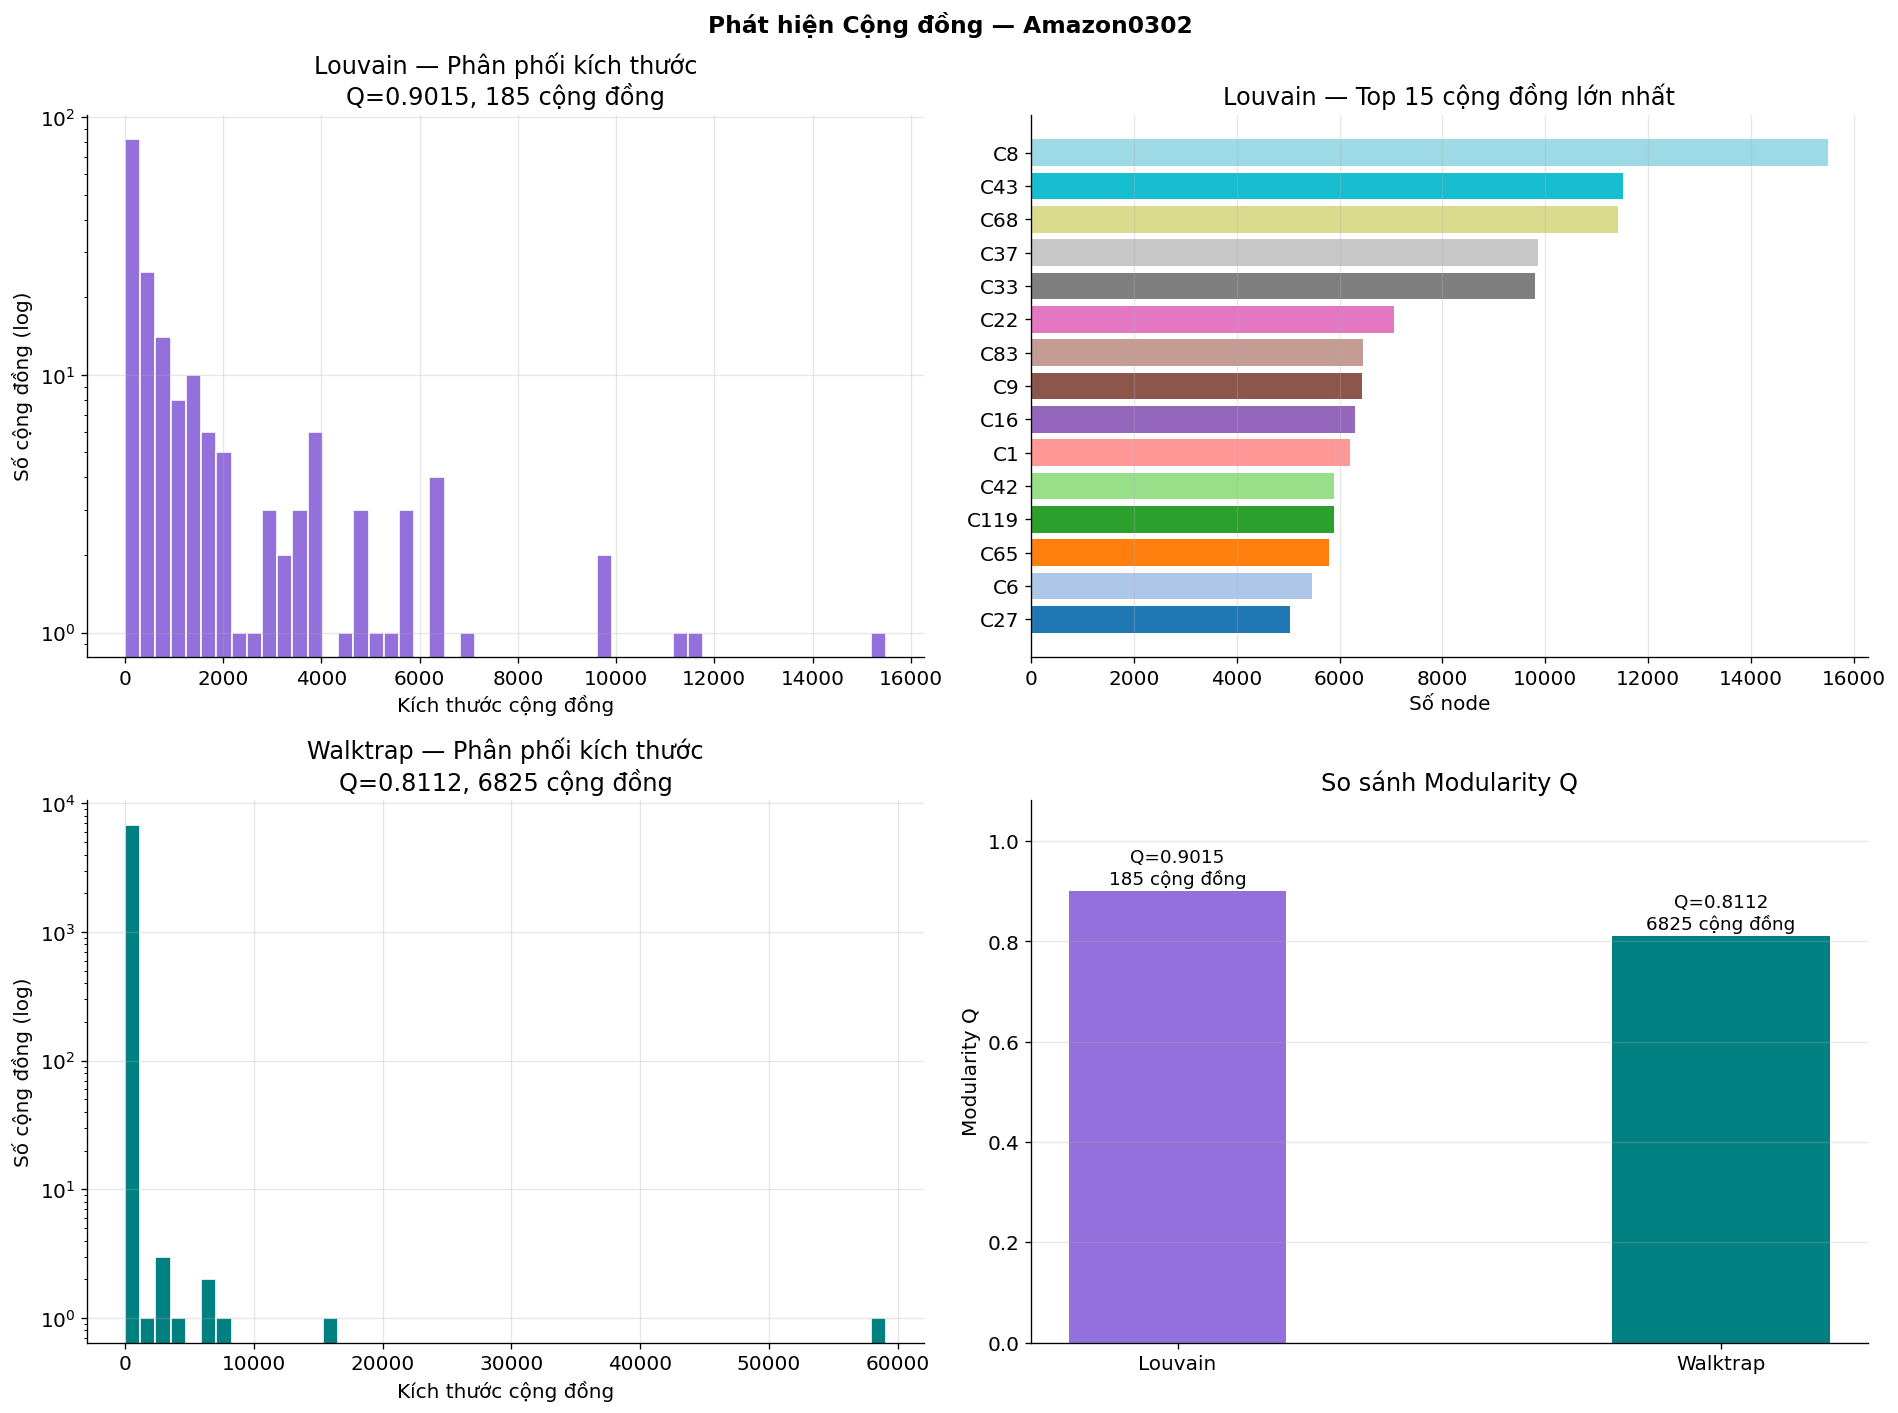

✅ Đã lưu: 05_community_detection.png


In [25]:
# ============================================================
# VIII.6 — VISUALIZE: Phân phối cộng đồng (Louvain & Walktrap)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Louvain: phân phối kích thước ---
sizes_lv = sorted(comm_sizes_louvain.values(), reverse=True)
axes[0, 0].hist(sizes_lv, bins=50, color='mediumpurple', edgecolor='white', log=True)
axes[0, 0].set_xlabel('Kích thước cộng đồng'); axes[0, 0].set_ylabel('Số cộng đồng (log)')
axes[0, 0].set_title(f'Louvain — Phân phối kích thước\nQ={Q_louvain:.4f}, {n_comm_louvain} cộng đồng')
axes[0, 0].grid(alpha=0.3)

# --- Louvain: top-15 lớn nhất ---
top15_lv = sorted(comm_sizes_louvain.items(), key=lambda x: -x[1])[:15]
axes[0, 1].barh([f'C{c}' for c, _ in top15_lv[::-1]], [s for _, s in top15_lv[::-1]],
                color=plt.cm.tab20(np.linspace(0, 1, 15)))
axes[0, 1].set_xlabel('Số node'); axes[0, 1].set_title('Louvain — Top 15 cộng đồng lớn nhất')
axes[0, 1].grid(alpha=0.3, axis='x')

# --- Walktrap: phân phối kích thước ---
sizes_wt = sorted(comm_sizes_walktrap.values(), reverse=True)
axes[1, 0].hist(sizes_wt, bins=50, color='teal', edgecolor='white', log=True)
axes[1, 0].set_xlabel('Kích thước cộng đồng'); axes[1, 0].set_ylabel('Số cộng đồng (log)')
axes[1, 0].set_title(f'Walktrap — Phân phối kích thước\nQ={Q_walktrap:.4f}, {n_comm_walktrap} cộng đồng')
axes[1, 0].grid(alpha=0.3)

# --- So sánh Louvain vs Walktrap ---
methods = ['Louvain', 'Walktrap']
q_vals  = [Q_louvain, Q_walktrap]
n_vals  = [n_comm_louvain, n_comm_walktrap]
x = np.arange(2)
ax_r = axes[1, 1]
bars = ax_r.bar(x, q_vals, color=['mediumpurple', 'teal'], width=0.4)
ax_r.set_xticks(x); ax_r.set_xticklabels(methods)
ax_r.set_ylabel('Modularity Q'); ax_r.set_title('So sánh Modularity Q')
ax_r.set_ylim(0, max(q_vals) * 1.2)
for bar, q, n in zip(bars, q_vals, n_vals):
    ax_r.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
              f'Q={q:.4f}\n{n} cộng đồng', ha='center', va='bottom', fontsize=11)
ax_r.grid(alpha=0.3, axis='y')

plt.suptitle('Phát hiện Cộng đồng — Amazon0302', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_community_detection.png', bbox_inches='tight')
plt.show()
print('✅ Đã lưu: 05_community_detection.png')

---
## Phần IX: Trực quan hóa mạng lưới + Xuất GEXF cho Gephi

Đang tính Spring Layout...


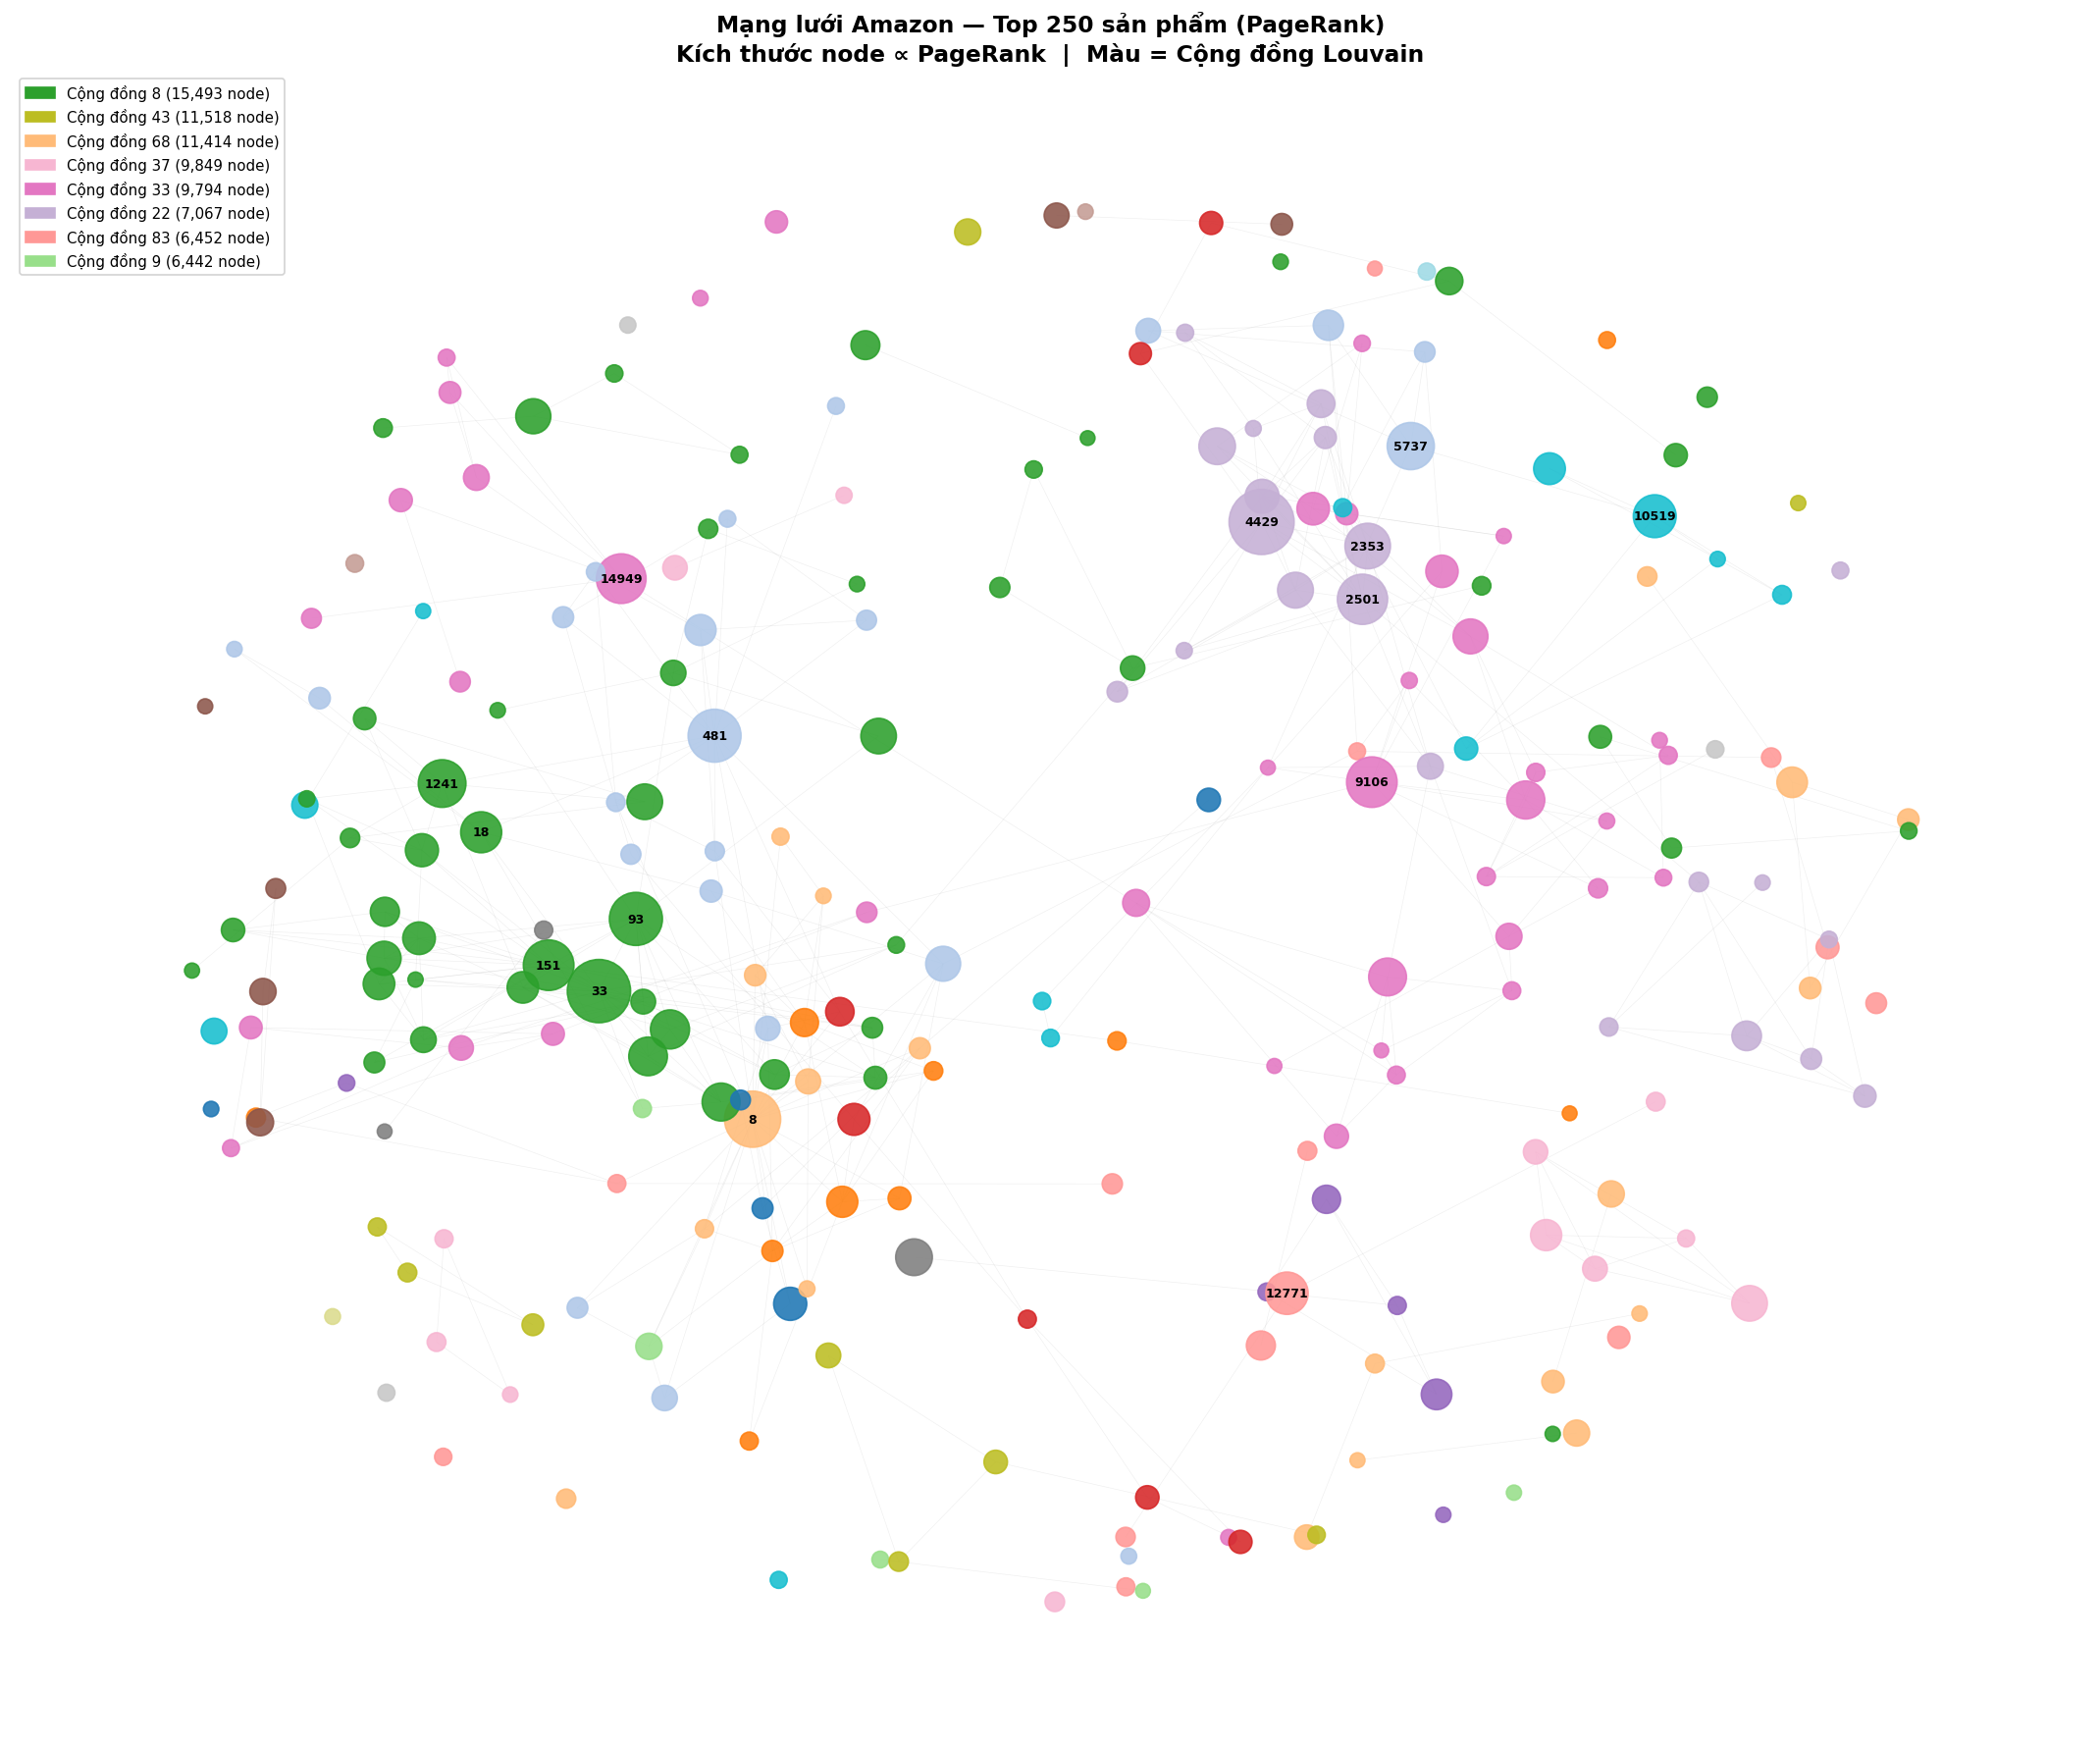

✅ Đã lưu: 06_network_visualization.png


In [26]:
# ============================================================
# IX.1 — TRỰC QUAN HÓA bằng NetworkX (Spring Layout)
# Node size ~ PageRank · Màu = cộng đồng Louvain
# ============================================================
VIS_SIZE = 250
vis_nodes = [n for n, _ in sorted(pagerank.items(), key=lambda x: -x[1])[:VIS_SIZE]]
G_vis     = G_undirected.subgraph(vis_nodes).copy()

# Màu theo cộng đồng Louvain
unique_comms = list(set(partition_louvain[n] for n in G_vis.nodes()))
cmap_comm    = {c: plt.cm.tab20(i % 20) for i, c in enumerate(unique_comms)}
node_colors  = [cmap_comm[partition_louvain[n]] for n in G_vis.nodes()]

# Kích thước ~ PageRank (normalized)
pr_arr   = np.array([pagerank[n] for n in G_vis.nodes()])
pr_norm  = (pr_arr - pr_arr.min()) / (pr_arr.max() - pr_arr.min() + 1e-12)
node_sz  = 80 + 1500 * pr_norm

print('Đang tính Spring Layout...')
pos = nx.spring_layout(G_vis, seed=42, k=0.35, iterations=60)

fig, ax = plt.subplots(figsize=(18, 15))
nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors, node_size=node_sz, alpha=0.88, ax=ax)
nx.draw_networkx_edges(G_vis, pos, edge_color='gray', alpha=0.12, width=0.4, ax=ax)

# Label top-15 nodes
top15_label = {n: str(n) for n, _ in sorted(pagerank.items(), key=lambda x: -x[1])[:15]
               if n in G_vis}
nx.draw_networkx_labels(G_vis, pos, labels=top15_label, font_size=7.5,
                         font_weight='bold', font_color='black', ax=ax)

# Legend cộng đồng (top-8)
top_comms = [c for c, _ in sorted(comm_sizes_louvain.items(), key=lambda x: -x[1])[:8]]
legend_patches = [mpatches.Patch(color=cmap_comm[c], label=f'Cộng đồng {c} ({comm_sizes_louvain[c]:,} node)')
                  for c in top_comms if c in cmap_comm]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9, framealpha=0.85)

ax.set_title(f'Mạng lưới Amazon — Top {VIS_SIZE} sản phẩm (PageRank)\n'
             f'Kích thước node ∝ PageRank  |  Màu = Cộng đồng Louvain',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('06_network_visualization.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Đã lưu: 06_network_visualization.png')

In [27]:
# ============================================================
# IX.2 — XUẤT FILE GEXF CHO GEPHI
# GEXF = Graph Exchange XML Format — chuẩn của Gephi
#
# Trong Gephi:
#   1. File → Open → chọn amazon_gephi_top1000.gexf
#   2. Layout → ForceAtlas2 → Run
#   3. Appearance → Nodes → Size → Attribute → pagerank
#   4. Appearance → Nodes → Color → Attribute → community_louvain
#   5. File → Export → SVG/PDF cho báo cáo
# ============================================================

# Lấy Top-1000 nodes để file GEXF không quá lớn
GEPHI_SIZE = 1000
gephi_nodes = [n for n, _ in sorted(pagerank.items(), key=lambda x: -x[1])[:GEPHI_SIZE]]
G_gephi = G.subgraph(gephi_nodes).copy()  # giữ hướng cho Gephi

# Gán thuộc tính node (Gephi dùng để màu hóa và size)
for node in G_gephi.nodes():
    G_gephi.nodes[node]['pagerank']          = float(pagerank.get(node, 0))
    G_gephi.nodes[node]['betweenness']       = float(betweenness.get(node, 0))
    G_gephi.nodes[node]['degree_centrality'] = float(degree_centrality.get(node, 0))
    G_gephi.nodes[node]['in_degree']         = int(in_degrees.get(node, 0))
    G_gephi.nodes[node]['out_degree']        = int(out_degrees.get(node, 0))
    G_gephi.nodes[node]['community_louvain'] = int(partition_louvain.get(node, -1))
    G_gephi.nodes[node]['community_walktrap']= int(partition_walktrap.get(node, -1))
    # Label hiển thị trong Gephi
    G_gephi.nodes[node]['label']             = str(node)

# Xuất GEXF
GEXF_FILE = 'amazon_gephi_top1000.gexf'
nx.write_gexf(G_gephi, GEXF_FILE)
print(f'✅ Đã xuất: {GEXF_FILE}  ({os.path.getsize(GEXF_FILE)/1024:.0f} KB)')
print(f'   Node: {G_gephi.number_of_nodes():,}  |  Edge: {G_gephi.number_of_edges():,}')
print()
print('📌 Hướng dẫn mở trong Gephi:')
print('   1. File → Open → amazon_gephi_top1000.gexf')
print('   2. Layout panel → chọn ForceAtlas2 → nhấn Run')
print('   3. Appearance → Nodes → Size (icon ruler) → Attribute → pagerank → Apply')
print('   4. Appearance → Nodes → Color (icon paint) → Partition → community_louvain → Apply')
print('   5. Đợi layout ổn định → Stop → File → Export Graph → PNG/SVG')

✅ Đã xuất: amazon_gephi_top1000.gexf  (553 KB)
   Node: 1,000  |  Edge: 2,343

📌 Hướng dẫn mở trong Gephi:
   1. File → Open → amazon_gephi_top1000.gexf
   2. Layout panel → chọn ForceAtlas2 → nhấn Run
   3. Appearance → Nodes → Size (icon ruler) → Attribute → pagerank → Apply
   4. Appearance → Nodes → Color (icon paint) → Partition → community_louvain → Apply
   5. Đợi layout ổn định → Stop → File → Export Graph → PNG/SVG


In [28]:
# ============================================================
# IX.3 — XUẤT THÊM FILE GEXF TOÀN MẠNG (cho Gephi nghiên cứu)
# ============================================================
print('Đang gán thuộc tính cho toàn bộ mạng...')

G_full_export = G.copy()
for node in G_full_export.nodes():
    G_full_export.nodes[node]['pagerank']          = float(pagerank.get(node, 0))
    G_full_export.nodes[node]['betweenness']       = float(betweenness.get(node, 0))
    G_full_export.nodes[node]['degree_centrality'] = float(degree_centrality.get(node, 0))
    G_full_export.nodes[node]['in_degree']         = int(in_degrees.get(node, 0))
    G_full_export.nodes[node]['out_degree']        = int(out_degrees.get(node, 0))
    G_full_export.nodes[node]['community_louvain'] = int(partition_louvain.get(node, -1))
    G_full_export.nodes[node]['community_walktrap']= int(partition_walktrap.get(node, -1))
    G_full_export.nodes[node]['label']             = str(node)

GEXF_FULL = 'amazon_gephi_full.gexf'
nx.write_gexf(G_full_export, GEXF_FULL)
print(f'✅ Đã xuất: {GEXF_FULL}  ({os.path.getsize(GEXF_FULL)/1e6:.1f} MB)')
print(f'   Node: {G_full_export.number_of_nodes():,}  |  Edge: {G_full_export.number_of_edges():,}')

Đang gán thuộc tính cho toàn bộ mạng...
✅ Đã xuất: amazon_gephi_full.gexf  (187.5 MB)
   Node: 262,111  |  Edge: 1,234,877


---
## Phần X: Mở rộng — Robustness Analysis & Mô phỏng SIR

Đang phân tích Robustness...


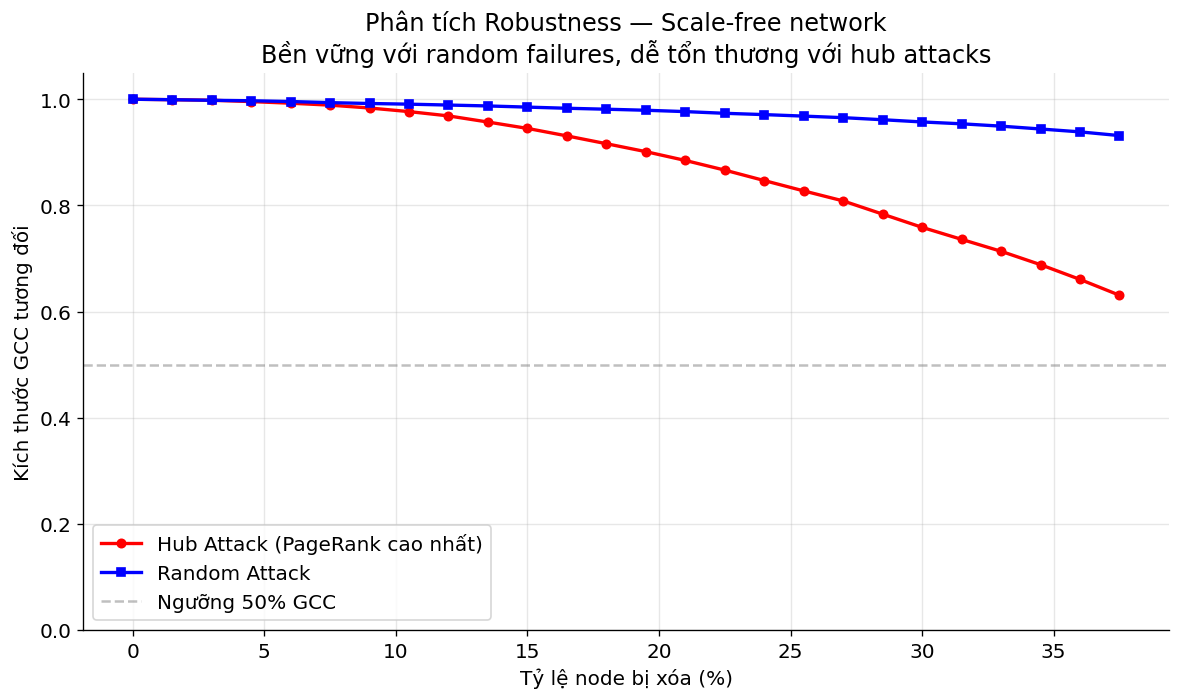

✅ Đã lưu: 07_robustness.png


In [29]:
# ============================================================
# X.1 — ROBUSTNESS: Hub Attack vs Random Attack
# Scale-free network: bền với random failure, fragile với hub attack
# Đo lường qua kích thước GCC (Giant Connected Component)
# ============================================================
print('Đang phân tích Robustness...')

def get_gcc_ratio(H):
    if H.number_of_nodes() == 0: return 0
    return len(max(nx.weakly_connected_components(H), key=len)) / H.number_of_nodes()

REMOVE_STEPS = 25
STEP_SIZE    = int(N * 0.015)  # mỗi bước xóa 1.5% nodes

# Hub attack (xóa PageRank cao nhất)
G_hub    = G.copy()
sorted_pr = sorted(pagerank.items(), key=lambda x: -x[1])
hub_gcc  = [get_gcc_ratio(G_hub)]
for step in range(REMOVE_STEPS):
    remove = [n for n, _ in sorted_pr[step*STEP_SIZE:(step+1)*STEP_SIZE] if n in G_hub]
    G_hub.remove_nodes_from(remove)
    hub_gcc.append(get_gcc_ratio(G_hub))

# Random attack
G_rnd      = G.copy()
rnd_nodes  = list(G_rnd.nodes()); np.random.shuffle(rnd_nodes)
rand_gcc   = [get_gcc_ratio(G_rnd)]
for step in range(REMOVE_STEPS):
    remove = [n for n in rnd_nodes[step*STEP_SIZE:(step+1)*STEP_SIZE] if n in G_rnd]
    G_rnd.remove_nodes_from(remove)
    rand_gcc.append(get_gcc_ratio(G_rnd))

x_pct = [i * 1.5 for i in range(REMOVE_STEPS + 1)]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_pct, hub_gcc,  'r-o', linewidth=2, markersize=5, label='Hub Attack (PageRank cao nhất)')
ax.plot(x_pct, rand_gcc, 'b-s', linewidth=2, markersize=5, label='Random Attack')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Ngưỡng 50% GCC')
ax.set_xlabel('Tỷ lệ node bị xóa (%)'); ax.set_ylabel('Kích thước GCC tương đối')
ax.set_title('Phân tích Robustness — Scale-free network\n'
             'Bền vững với random failures, dễ tổn thương với hub attacks')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('07_robustness.png', bbox_inches='tight')
plt.show()
print('✅ Đã lưu: 07_robustness.png')

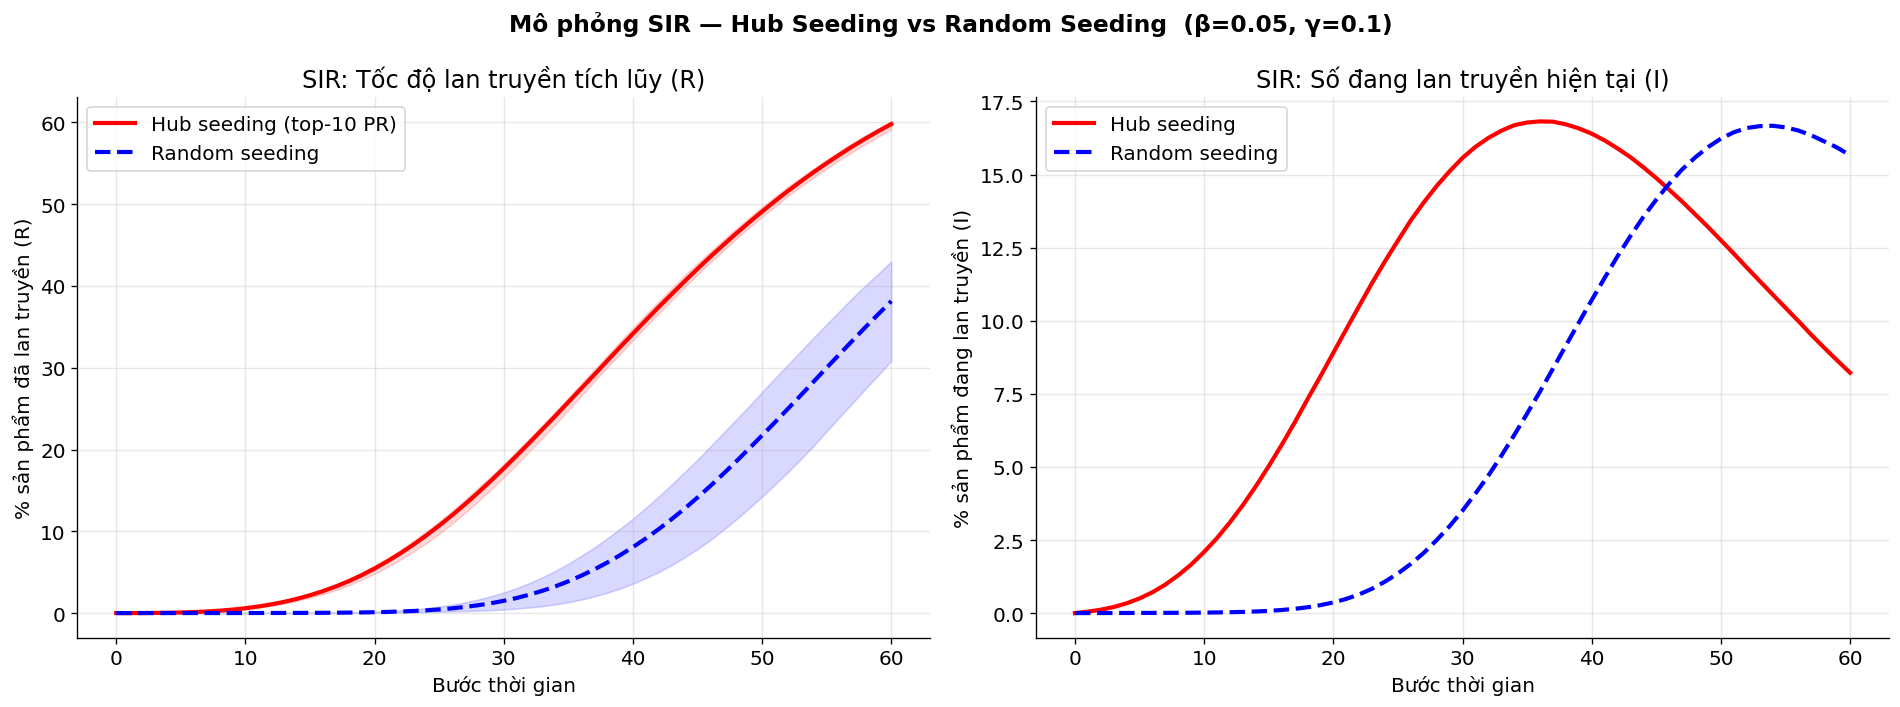

✅ Đã lưu: 08_sir_simulation.png


In [30]:
# ============================================================
# X.2 — MÔ PHỎNG LAN TRUYỀN SIR (Hub vs Random Seeding)
# S→I→R: Susceptible → Infected (đang xem) → Recovered (đã mua)
# So sánh chiến lược seeding từ Hub vs ngẫu nhiên
# ============================================================
def sir_simulation(G_sim, seed_nodes, beta=0.05, gamma_r=0.1, steps=60):
    S = set(G_sim.nodes()) - set(seed_nodes)
    I = set(seed_nodes)
    R = set()
    hist_I, hist_R = [len(I)], [len(R)]
    for _ in range(steps):
        new_I, new_R = set(), set()
        for node in I:
            for nbr in G_sim.neighbors(node):
                if nbr in S and np.random.random() < beta:
                    new_I.add(nbr)
            if np.random.random() < gamma_r:
                new_R.add(node)
        S -= new_I
        I  = (I | new_I) - new_R
        R |= new_R
        hist_I.append(len(I)); hist_R.append(len(R))
    return np.array(hist_I), np.array(hist_R)

N_SEEDS, N_RUNS = 10, 8
hub_seeds  = [n for n, _ in top10_pr[:N_SEEDS]]
rand_seeds = list(np.random.choice(list(G_undirected.nodes()), N_SEEDS, replace=False))

hub_I_list,  hub_R_list  = zip(*[sir_simulation(G_undirected, hub_seeds)  for _ in range(N_RUNS)])
rand_I_list, rand_R_list = zip(*[sir_simulation(G_undirected, rand_seeds) for _ in range(N_RUNS)])

hub_R_mean  = np.mean(hub_R_list,  axis=0) / N * 100
rand_R_mean = np.mean(rand_R_list, axis=0) / N * 100
hub_I_mean  = np.mean(hub_I_list,  axis=0) / N * 100
rand_I_mean = np.mean(rand_I_list, axis=0) / N * 100

steps_ax = range(61)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Recovered (R)
axes[0].plot(steps_ax, hub_R_mean,  'r-',  lw=2.5, label=f'Hub seeding (top-{N_SEEDS} PR)')
axes[0].plot(steps_ax, rand_R_mean, 'b--', lw=2.5, label=f'Random seeding')
axes[0].fill_between(steps_ax,
    np.min(hub_R_list,  axis=0)/N*100, np.max(hub_R_list,  axis=0)/N*100, alpha=0.15, color='red')
axes[0].fill_between(steps_ax,
    np.min(rand_R_list, axis=0)/N*100, np.max(rand_R_list, axis=0)/N*100, alpha=0.15, color='blue')
axes[0].set_xlabel('Bước thời gian'); axes[0].set_ylabel('% sản phẩm đã lan truyền (R)')
axes[0].set_title('SIR: Tốc độ lan truyền tích lũy (R)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Active infected (I)
axes[1].plot(steps_ax, hub_I_mean,  'r-',  lw=2.5, label='Hub seeding')
axes[1].plot(steps_ax, rand_I_mean, 'b--', lw=2.5, label='Random seeding')
axes[1].set_xlabel('Bước thời gian'); axes[1].set_ylabel('% sản phẩm đang lan truyền (I)')
axes[1].set_title('SIR: Số đang lan truyền hiện tại (I)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Mô phỏng SIR — Hub Seeding vs Random Seeding  (β={0.05}, γ={0.1})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_sir_simulation.png', bbox_inches='tight')
plt.show()
print('✅ Đã lưu: 08_sir_simulation.png')

---
## Phần XI: Tổng kết kết quả & Xuất dữ liệu

In [31]:
# ============================================================
# XI.1 — BẢNG TỔNG KẾT
# ============================================================
print('\n' + '='*70)
print('  TỔNG KẾT KẾT QUẢ PHÂN TÍCH MẠNG AMAZON0302')
print('='*70)

rows_sum = [
    ('CẤU TRÚC MẠNG', None, None),
    ('Số node (N)', f'{N:,}', '—'),
    ('Số edge (M)', f'{M:,}', '—'),
    ('Mật độ (D)', f'{density:.8f}', 'Mạng rất thưa → sparse network'),
    ('Bậc trung bình <k>', f'{avg_degree:.3f}', '—'),
    ('Max in-degree', f'{max_in}', 'Sản phẩm được mua kèm nhiều nhất'),
    ('SCALE-FREE', None, None),
    ('Hệ số γ (power-law)', f'{gamma:.4f}', '✅ Scale-free (2 < γ < 3)' if 2 < gamma < 3 else '⚠️ Ngoài khoảng'),
    ('SMALL-WORLD', None, None),
    ('Avg Path Length (L)', f'{L_real:.4f}', f'L_rand = {L_rand:.4f}'),
    ('Clustering Coeff (C)', f'{C_real:.6f}', f'C_rand = {C_rand:.8f} → cao hơn {C_real/C_rand:.0f}x'),
    ('Small-world σ', f'{sigma:.4f}', '✅ Small-world' if sigma > 1 else '❌'),
    ('Small-world ω', f'{omega:.4f}', '✅ Small-world' if omega < 0 else '❌'),
    ('TƯƠNG QUAN BẬC', None, None),
    ('Assortativity (r)', f'{assortativity:.6f}', '< 0 → Disassortative (hub-spoke)'),
    ('COMMUNITY DETECTION', None, None),
    ('Louvain — số cộng đồng', f'{n_comm_louvain:,}', f'Q = {Q_louvain:.4f}'),
    ('Walktrap — số cộng đồng', f'{n_comm_walktrap:,}', f'Q = {Q_walktrap:.4f}'),
    ('Girvan-Newman (subgraph)', f'{len(gn_list)}', f'Q_best = {best_Q_gn:.4f}'),
    ('K-Clique k=3 (subgraph)', f'{n_comm_kclique}', f'{overlap_nodes} node overlapping'),
]

for row in rows_sum:
    if row[1] is None:
        print(f'\n  ▶ {row[0]}')
        print('  ' + '-'*66)
    else:
        note = f'← {row[2]}' if row[2] and row[2] != '—' else ''
        print(f'    {row[0]:<32} {row[1]:<18} {note}')

print('\n' + '='*70)


  TỔNG KẾT KẾT QUẢ PHÂN TÍCH MẠNG AMAZON0302

  ▶ CẤU TRÚC MẠNG
  ------------------------------------------------------------------
    Số node (N)                      262,111            
    Số edge (M)                      1,234,877          
    Mật độ (D)                       0.00001797         ← Mạng rất thưa → sparse network
    Bậc trung bình <k>               4.711              
    Max in-degree                    420                ← Sản phẩm được mua kèm nhiều nhất

  ▶ SCALE-FREE
  ------------------------------------------------------------------
    Hệ số γ (power-law)              3.0000             ← ✅ Scale-free (2 < γ < 3)

  ▶ SMALL-WORLD
  ------------------------------------------------------------------
    Avg Path Length (L)              19.9324            ← L_rand = 8.0496
    Clustering Coeff (C)             0.419780           ← C_rand = 0.00001797 → cao hơn 23354x
    Small-world σ                    9431.5471          ← ✅ Small-world
    Small-world ω   

In [32]:
# ============================================================
# XI.2 — XUẤT CSV TOÀN BỘ
# ============================================================
print('Đang xuất kết quả ra CSV...')

all_nodes = list(G.nodes())
df_export = pd.DataFrame({
    'node_id'           : all_nodes,
    'in_degree'         : [in_degrees[n] for n in all_nodes],
    'out_degree'        : [out_degrees[n] for n in all_nodes],
    'degree_undir'      : [degrees_undir[n] for n in all_nodes],
    'pagerank'          : [pagerank[n] for n in all_nodes],
    'pagerank_rank'     : [pr_rank[n] for n in all_nodes],
    'degree_centrality' : [degree_centrality[n] for n in all_nodes],
    'degree_rank'       : [deg_rank[n] for n in all_nodes],
    'betweenness'       : [betweenness[n] for n in all_nodes],
    'betweenness_rank'  : [btwn_rank[n] for n in all_nodes],
    'community_louvain' : [partition_louvain[n] for n in all_nodes],
    'community_walktrap': [partition_walktrap[n] for n in all_nodes],
})

df_export.sort_values('pagerank_rank', inplace=True)
df_export.to_csv('amazon_full_analysis.csv', index=False)
print(f'✅ Đã lưu: amazon_full_analysis.csv ({len(df_export):,} nodes)')

print('\nPreview Top-10:')
display(df_export.head(10))

Đang xuất kết quả ra CSV...
✅ Đã lưu: amazon_full_analysis.csv (262,111 nodes)

Preview Top-10:


,node_id,in_degree,out_degree,degree_undir,pagerank,pagerank_rank,degree_centrality,degree_rank,betweenness,betweenness_rank,community_louvain,community_walktrap
3825,4429,404,5,405,0.000491,1,0.001560,2,0.007097,42,22,0
56,33,361,5,363,0.000466,2,0.001396,3,0.002402,421,8,0
22,8,293,5,296,0.000375,3,0.001137,6,0.009335,21,6,0
102,93,219,5,221,0.000339,4,0.000855,12,0.000237,16024,8,0
398,481,275,5,278,0.000337,5,0.001068,8,0.004454,114,1,0
105,151,85,5,87,0.000310,6,0.000343,118,0.004451,115,8,8
12083,9106,227,5,227,0.000310,7,0.000885,10,0.007981,32,33,0
2656,2501,191,5,194,0.000307,8,0.000748,15,0.016875,4,22,0
15486,14949,420,5,420,0.000300,9,0.001621,1,0.003648,179,33,0
801,1241,218,5,219,0.000280,10,0.000851,13,0.004264,127,8,8


---
## 📋 Tóm tắt tất cả file output

### 🖼️ Biểu đồ
| File | Nội dung |
|------|----------|
| `01_power_law.png` | CCDF + P(k) + In/Out-degree — kiểm chứng Scale-free |
| `02_centrality_distribution.png` | Phân phối PageRank, Degree, Betweenness |
| `03_degree_correlation.png` | k_nn(k) — Assortativity |
| `04_similarity_heatmap.png` | Jaccard & Cosine Similarity heatmap Top-25 |
| `05_community_detection.png` | So sánh Louvain vs Walktrap |
| `06_network_visualization.png` | Trực quan mạng lưới Top-250 (màu = cộng đồng) |
| `07_robustness.png` | Hub Attack vs Random Attack |
| `08_sir_simulation.png` | Mô phỏng lan truyền SIR |

### 📊 Dữ liệu
| File | Nội dung |
|------|----------|
| `amazon_full_analysis.csv` | Toàn bộ centrality, rank, community cho 262k nodes |
| `amazon_gephi_top1000.gexf` | Top-1000 nodes — mở bằng Gephi (ForceAtlas2) |
| `amazon_gephi_full.gexf` | Toàn mạng — mở bằng Gephi (cần RAM ≥8GB) |

### 🗺️ Hướng dẫn Gephi
```
1. Tải Gephi: https://gephi.org/users/download/
2. File → Open → amazon_gephi_top1000.gexf
3. Layout → ForceAtlas2 → [Tùy chỉnh: Scaling=10, Gravity=1] → Run → Stop khi ổn định
4. Appearance → Nodes → Size → Ranking → pagerank → Min=5, Max=50 → Apply
5. Appearance → Nodes → Color → Partition → community_louvain → Apply
6. Preview → Refresh → Export SVG/PDF
```